In [2]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

In [3]:
sample = pd.read_csv(
    "Downloads/nc_statewide_2020_04_01.csv",
    nrows=10
)
print(sample.columns)
print(sample.head())

Index(['raw_row_number', 'date', 'time', 'location', 'county_name',
       'subject_age', 'subject_race', 'subject_sex', 'officer_id_hash',
       'department_name', 'type', 'arrest_made', 'citation_issued',
       'warning_issued', 'outcome', 'contraband_found', 'contraband_drugs',
       'contraband_weapons', 'frisk_performed', 'search_conducted',
       'search_person', 'search_vehicle', 'search_basis', 'reason_for_frisk',
       'reason_for_search', 'reason_for_stop', 'raw_Ethnicity', 'raw_Race',
       'raw_action_description'],
      dtype='object')
   raw_row_number        date      time location  county_name  subject_age  \
0               1  2000-05-22  21:10:00  Unknown          NaN           45   
1               2  2000-01-03  07:52:00  Unknown          NaN           20   
2               3  2000-01-06  10:30:00  Unknown          NaN           23   
3               4  2000-01-06  14:50:00  Unknown          NaN           60   
4               5  2000-01-06  14:50:00  Unknown

In [5]:
df = pd.read_csv(
    "Downloads/nc_statewide_2020_04_01.csv",
    usecols = [
        'date', 
        'time', 
        'subject_age',
        'subject_race', 
        'subject_sex', 
        'type', 
        'arrest_made', 
        'citation_issued',
        'warning_issued', 
        'outcome', 
        'contraband_found', 
        'contraband_drugs',
        'contraband_weapons', 
        'frisk_performed',
        'search_conducted',
        'search_person', 
        'search_vehicle', 
        'search_basis', 
        'reason_for_frisk',
        'reason_for_search',
        'reason_for_stop',
        'raw_Ethnicity', 
        'raw_Race',
        'raw_action_description'
              ],
)

C:\Users\charl\AppData\Local\Temp\ipykernel_29564\489383693.py:1: DtypeWarning: Columns (2,15,16,17,22,23,24) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv(


In [6]:
df.head()
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 20286645 entries, 0 to 20286644
Data columns (total 24 columns):
 #   Column                  Dtype  
---  ------                  -----  
 0   date                    object 
 1   time                    object 
 2   subject_age             float64
 3   subject_race            object 
 4   subject_sex             object 
 5   type                    object 
 6   arrest_made             bool   
 7   citation_issued         bool   
 8   warning_issued          bool   
 9   outcome                 object 
 10  contraband_found        object 
 11  contraband_drugs        object 
 12  contraband_weapons      object 
 13  frisk_performed         bool   
 14  search_conducted        bool   
 15  search_person           bool   
 16  search_vehicle          bool   
 17  search_basis            object 
 18  reason_for_frisk        object 
 19  reason_for_search       object 
 20  reason_for_stop         object 
 21  raw_Ethnicity           objec

In [7]:
# Make a smaller DataFrame containing only the columns needed.
comparison = df[["date", "citation_issued"]].copy()

# Remove rows where either the date or citation value is missing.
comparison = comparison.dropna(subset=["date", "citation_issued"])

# Convert the date strings into actual pandas datetime values.
#
# %Y = four-digit year, such as 2010
# %m = month, such as 01
# %d = day, such as 01
comparison["date"] = pd.to_datetime(
    comparison["date"],
    format="%Y-%m-%d",
    errors="coerce"
)

# Check whether the conversion worked.
print(comparison["date"].head())
print("Invalid dates:", comparison["date"].isna().sum())



0   2000-05-22
1   2000-01-03
2   2000-01-06
3   2000-01-06
4   2000-01-06
Name: date, dtype: datetime64[ns]
Invalid dates: 0


In [8]:
# Check the earliest and latest dates in the cleaned data.
print("Earliest date:", comparison["date"].min())
print("Latest date:", comparison["date"].max())

Earliest date: 2000-01-01 00:00:00
Latest date: 2015-12-31 00:00:00


In [9]:
# STEP 6: Create a year-month column.
#
# dt gives access to datetime properties.
# to_period("M") reduces each full date to its year and month.
#
# For example:
# 04/17/2020 becomes 2020-04
# 04/29/2020 also becomes 2020-04
#
# Keeping the year is safer than extracting only the month name,
# especially if the dataset covers more than one year.
comparison["year_month"] = comparison["date"].dt.to_period("M")


In [10]:
# STEP 7: Count the number of non-null citation entries in each month.
#
# groupby("year_month") divides the rows into monthly groups.
#
# ["citation issued"].count() counts the non-null entries in that column
# within each monthly group.
monthly_counts = (
    comparison
    .groupby("year_month")["citation_issued"]
    .count()
)

In [11]:

# STEP 8: Display the monthly counts.
print(monthly_counts)



year_month
2000-01     49551
2000-02     55244
2000-03     62779
2000-04     53753
2000-05     57343
            ...  
2015-08    121629
2015-09    114313
2015-10    105871
2015-11    110986
2015-12    103720
Freq: M, Name: citation_issued, Length: 192, dtype: int64


<Axes: title={'center': 'Citations Issued by Month'}, xlabel='Month', ylabel='Number of citations'>

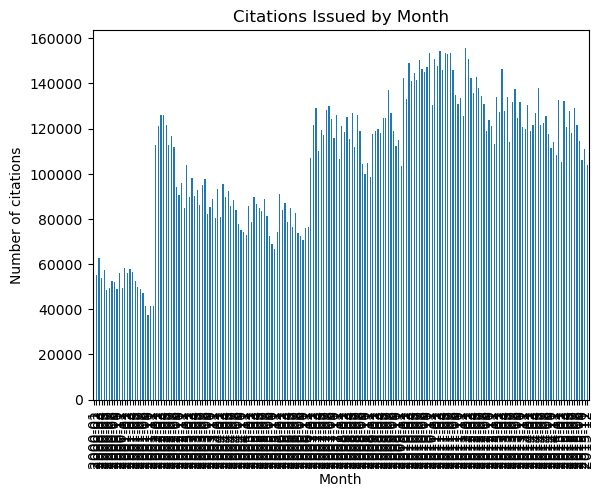

In [12]:

# STEP 9: Plot the results as a bar chart.
#
# A bar chart is appropriate because we are comparing counts across
# discrete monthly categories.
monthly_counts.plot(
    kind="bar",
    xlabel="Month",
    ylabel="Number of citations",
    title="Citations Issued by Month"
)



    year  month  citation_issued
0   2000      1            33648
1   2000      2            39137
2   2000      3            44898
3   2000      4            38955
4   2000      5            43217
5   2000      6            35498
6   2000      7            36720
7   2000      8            38962
8   2000      9            38535
9   2000     10            36319
10  2000     11            42021
11  2000     12            36933
12  2001      1            43599
13  2001      2            42266
14  2001      3            43624
15  2001      4            43699
16  2001      5            41004
17  2001      6            38374
18  2001      7            37923
19  2001      8            35537


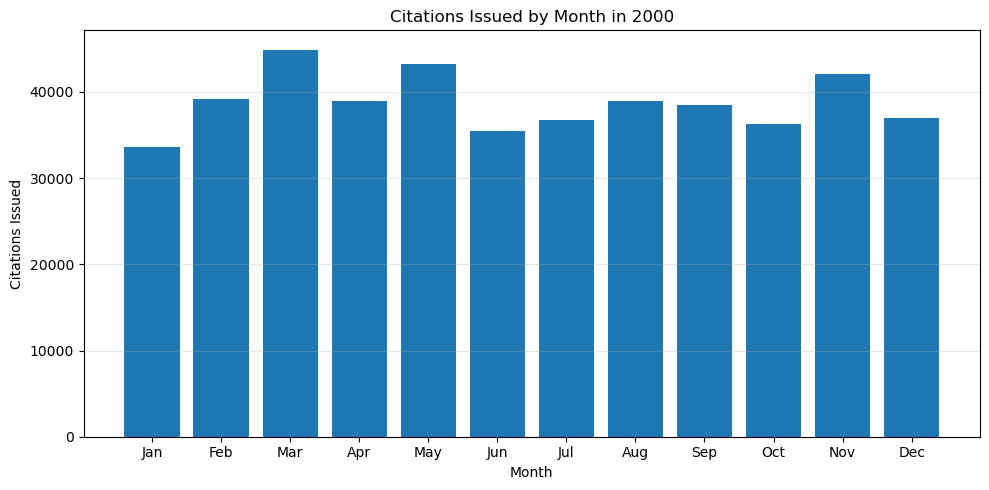

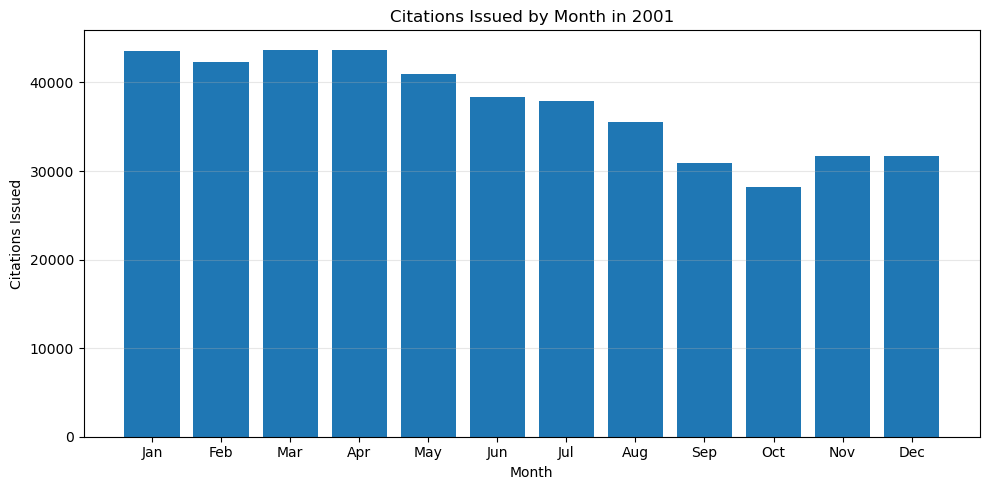

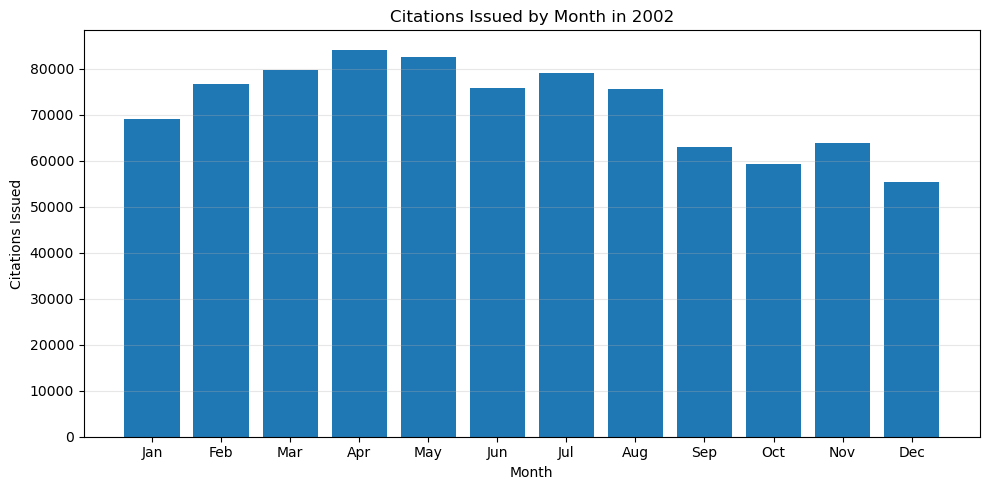

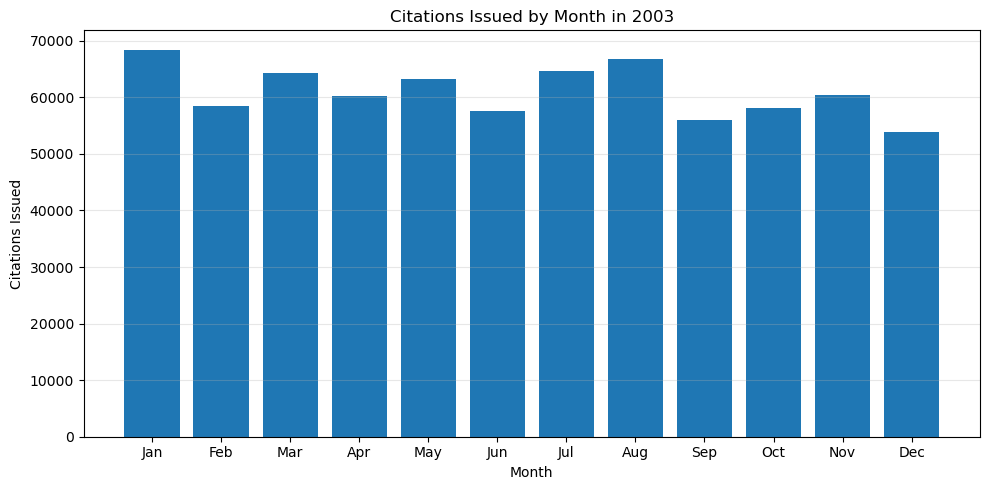

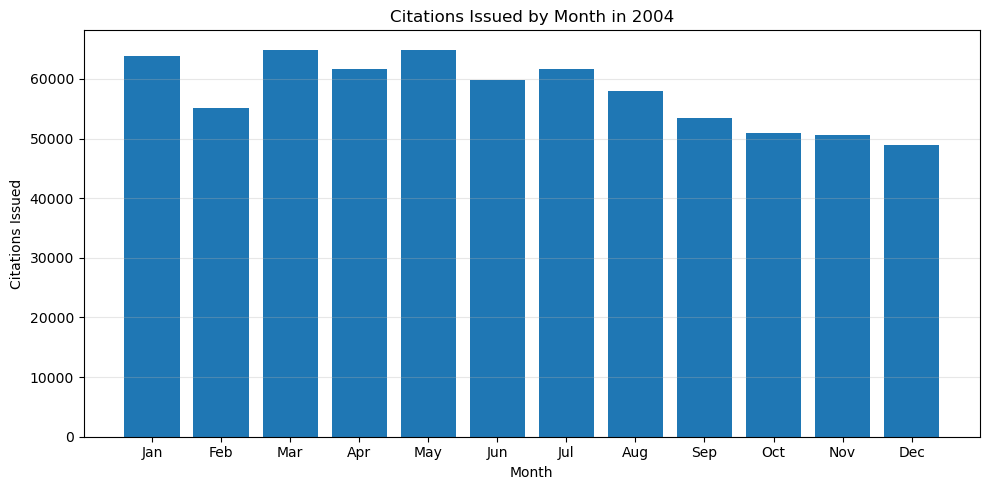

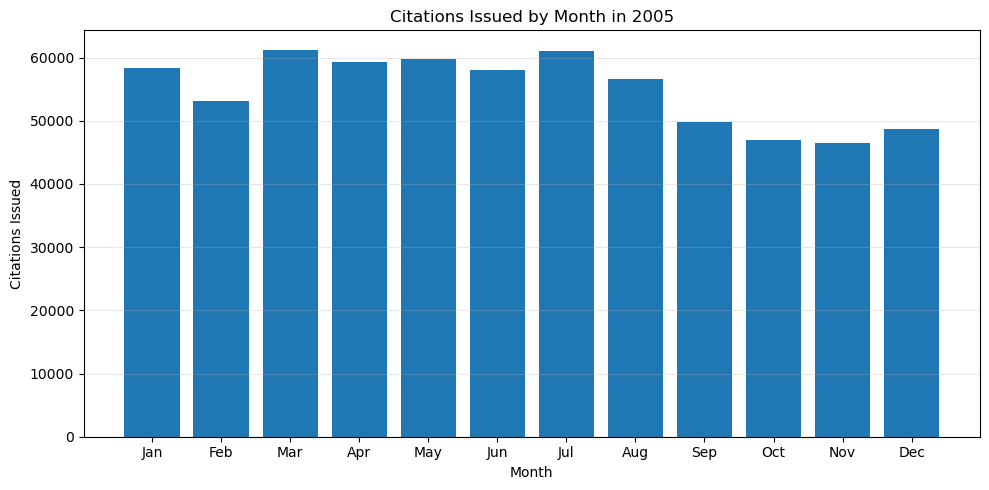

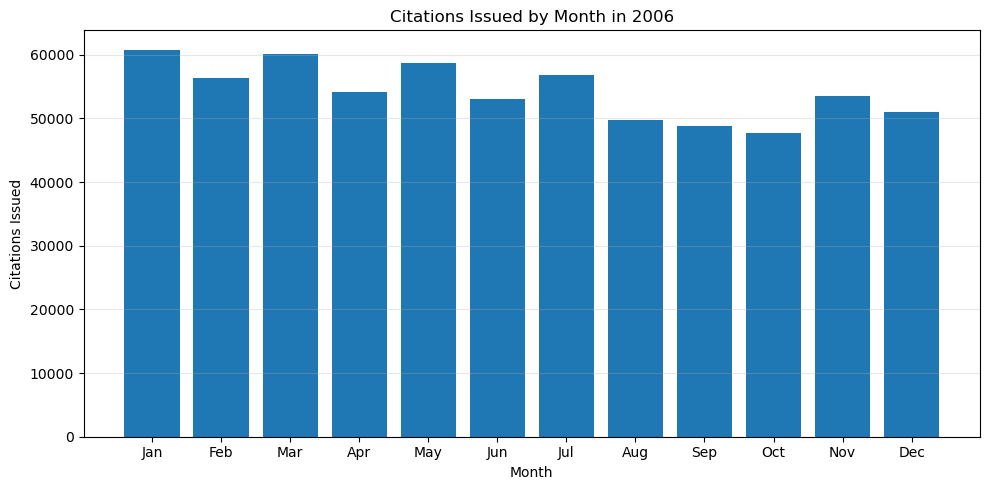

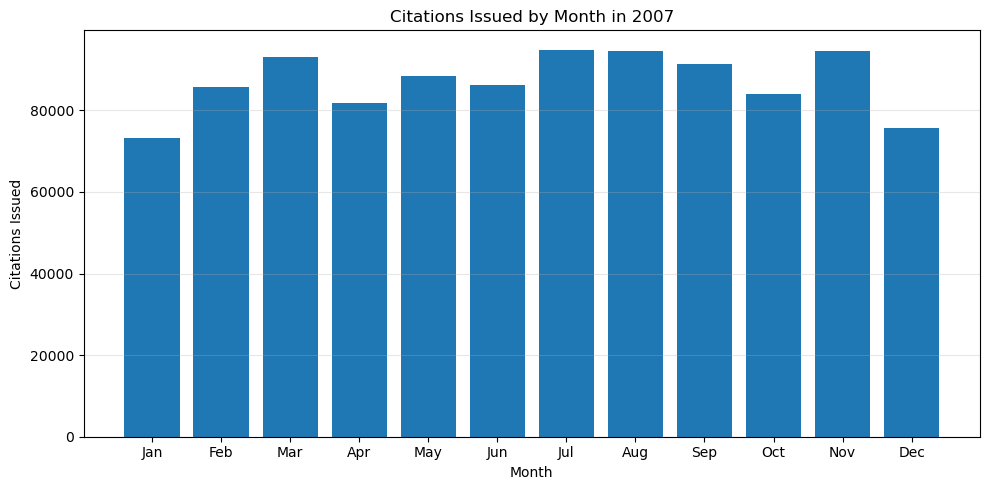

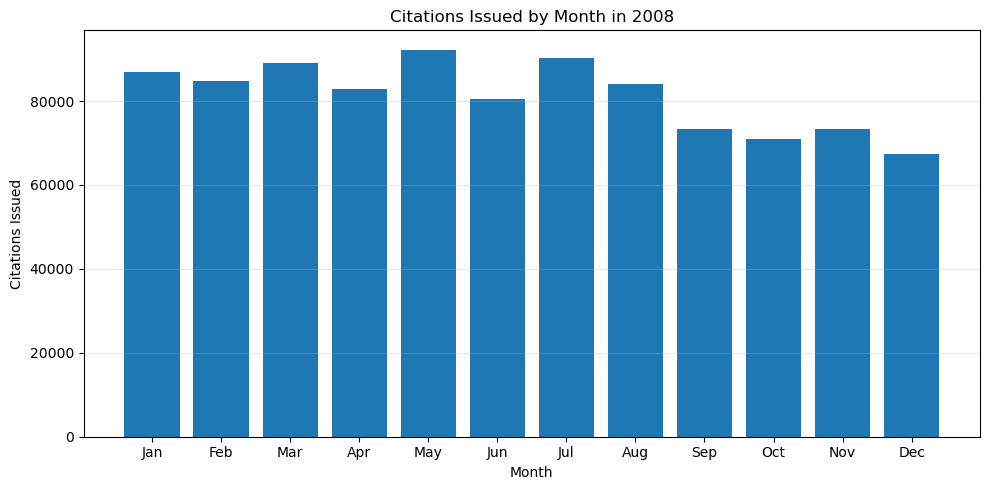

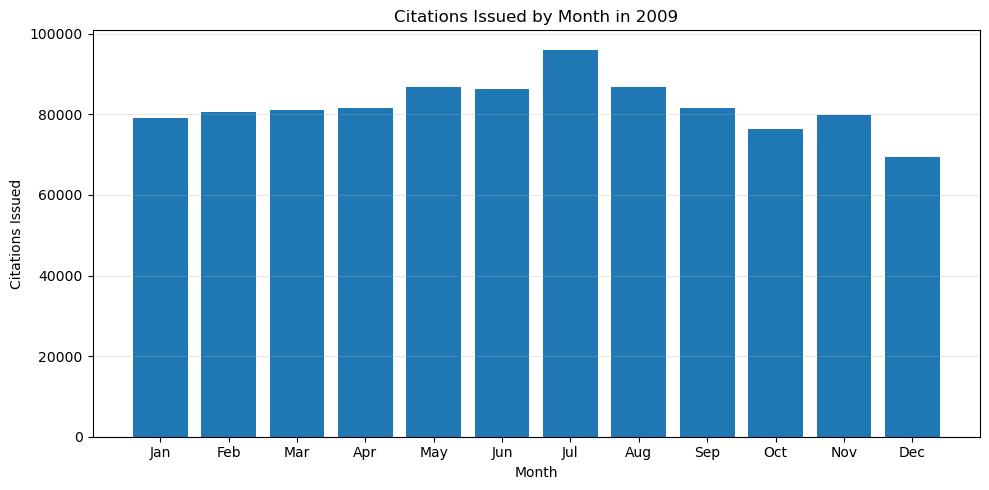

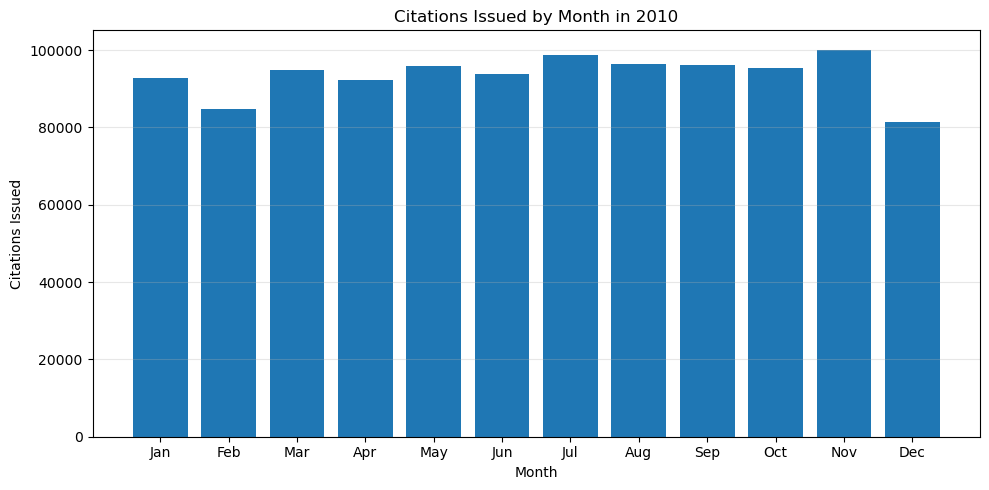

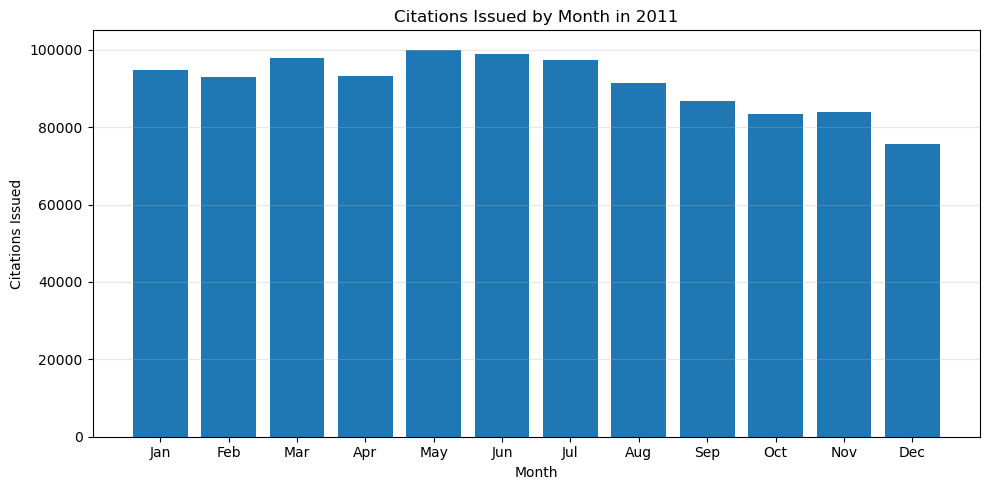

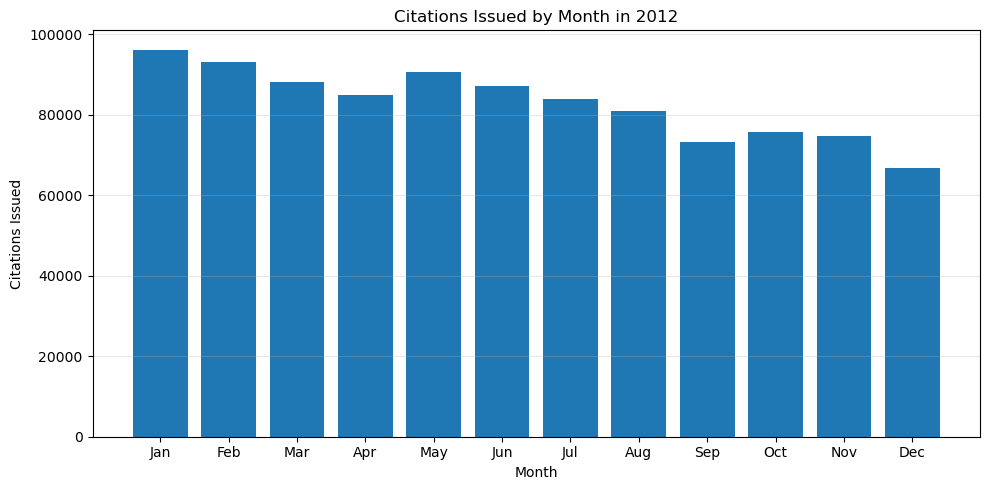

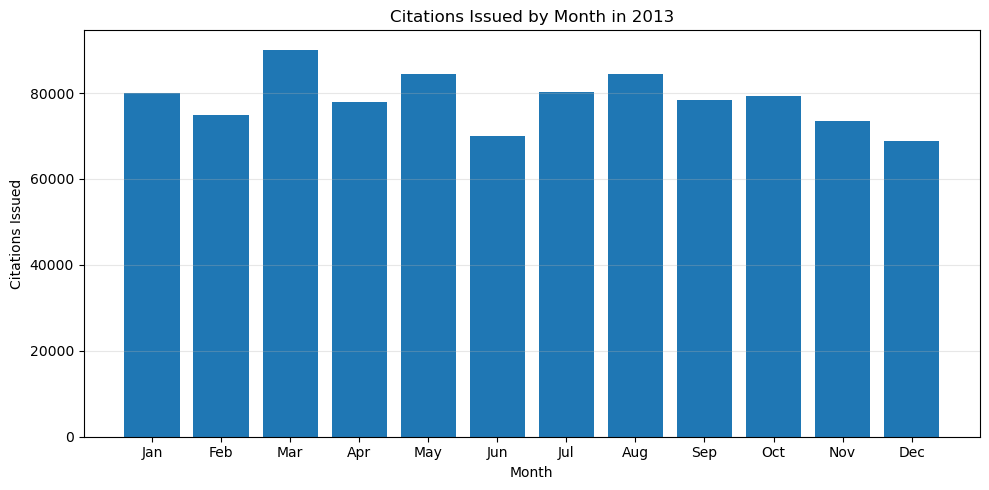

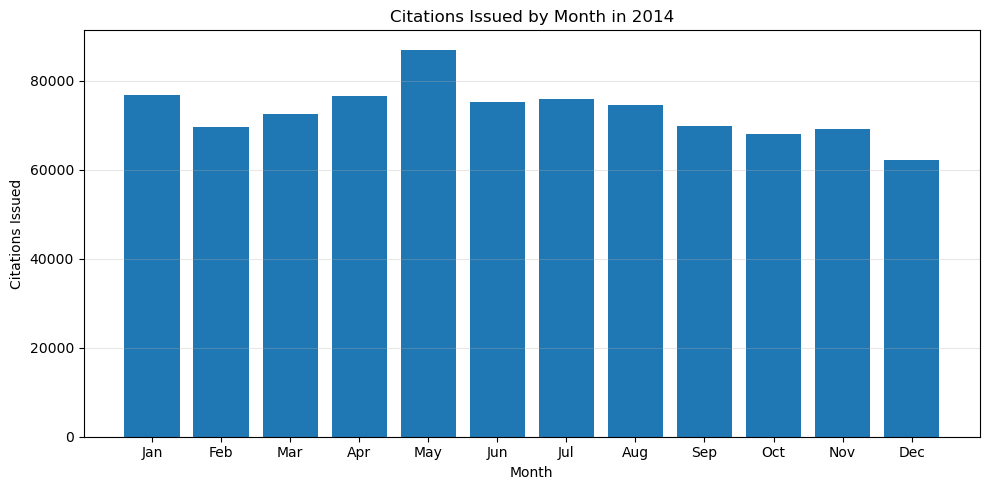

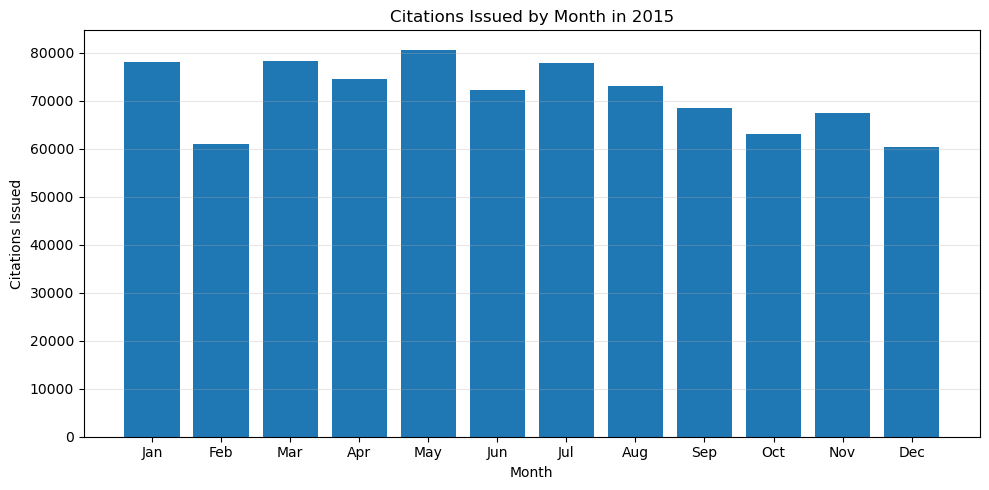

In [13]:
# ------------------------------------------------------------
# STEP 1: Convert the date column from text to datetime.
#
# Your dates look like "2010-01-01", so the format is:
# %Y = four-digit year
# %m = two-digit month
# %d = two-digit day
#
# errors="coerce" converts invalid dates to NaT rather than
# stopping the code with an error.
# ------------------------------------------------------------
df["date"] = pd.to_datetime(
    df["date"],
    format="%Y-%m-%d",
    errors="coerce"
)


# ------------------------------------------------------------
# STEP 2: Convert citation_issued to a numeric type.
#
# Since we originally read all columns as strings, pandas cannot
# yet perform arithmetic on citation_issued.
#
# Invalid or nonnumeric entries become NaN.
# ------------------------------------------------------------
df["citation_issued"] = pd.to_numeric(
    df["citation_issued"],
    errors="coerce"
)


# ------------------------------------------------------------
# STEP 3: Remove rows where either required value is missing.
#
# We need both a valid date and a valid citation value in order
# to assign the observation to a month and include it in a total.
# ------------------------------------------------------------
comparison = df.dropna(
    subset=["date", "citation_issued"]
).copy()


# ------------------------------------------------------------
# STEP 4: Extract the year and month from each date.
#
# For example, 2010-04-15 becomes:
# year  = 2010
# month = 4
# ------------------------------------------------------------
comparison["year"] = comparison["date"].dt.year
comparison["month"] = comparison["date"].dt.month


# ------------------------------------------------------------
# STEP 5: Add citation_issued values within each year and month.
#
# groupby(["year", "month"]) divides the data into groups such as:
# January 2010, February 2010, January 2011, and so on.
#
# .sum() calculates the total citation_issued value in each group.
# ------------------------------------------------------------
monthly_totals = (
    comparison
    .groupby(["year", "month"])["citation_issued"]
    .sum()
    .reset_index()
)


# Inspect the summarized data before plotting.
print(monthly_totals.head(20))


# ------------------------------------------------------------
# STEP 6: Create abbreviated month labels for the x-axis.
# ------------------------------------------------------------
month_names = [
    "Jan", "Feb", "Mar", "Apr",
    "May", "Jun", "Jul", "Aug",
    "Sep", "Oct", "Nov", "Dec"
]


# ------------------------------------------------------------
# STEP 7: Create one graph for every year.
#
# unique() finds all years in the data.
# sorted() places them in chronological order.
# ------------------------------------------------------------
for year in sorted(monthly_totals["year"].unique()):

    # Keep only the monthly totals for the current year.
    one_year = monthly_totals[
        monthly_totals["year"] == year
    ].copy()

    # Make the month number the index.
    #
    # reindex(range(1, 13)) ensures that every month appears,
    # including months with no citation data.
    #
    # fill_value=0 gives those missing months a total of zero.
    one_year = (
        one_year
        .set_index("month")
        .reindex(range(1, 13), fill_value=0)
    )
 # Start a new figure for this year.
    plt.figure(figsize=(10, 5))

    # Draw one bar for each month.
    plt.bar(
        month_names,
        one_year["citation_issued"]
    )

    # Add informative labels.
    plt.title(f"Citations Issued by Month in {year}")
    plt.xlabel("Month")
    plt.ylabel("Citations Issued")

    # Begin the y-axis at zero because bar heights represent totals.
    plt.ylim(bottom=0)

    # Add horizontal grid lines to make comparisons easier.
    plt.grid(axis="y", alpha=0.3)

    # Prevent labels from being cut off.
    plt.tight_layout()

    # Display this year's graph before moving to the next year.
    plt.show()


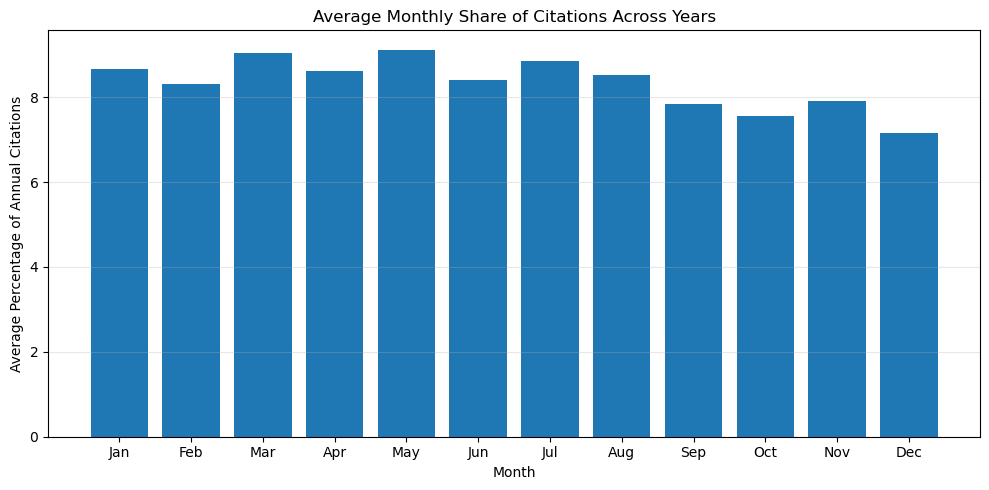

In [14]:
import pandas as pd
import matplotlib.pyplot as plt


# ------------------------------------------------------------
# STEP 1: Convert the columns into useful data types.
# ------------------------------------------------------------

# Convert date strings such as "2010-01-01" into datetime values.
df["date"] = pd.to_datetime(
    df["date"],
    format="%Y-%m-%d",
    errors="coerce"
)

# Convert citation_issued from text into numbers.
df["citation_issued"] = pd.to_numeric(
    df["citation_issued"],
    errors="coerce"
)


# ------------------------------------------------------------
# STEP 2: Remove rows where either required value is missing.
# ------------------------------------------------------------

comparison = df.dropna(
    subset=["date", "citation_issued"]
).copy()


# ------------------------------------------------------------
# STEP 3: Extract the year and month from each date.
# ------------------------------------------------------------

comparison["year"] = comparison["date"].dt.year
comparison["month"] = comparison["date"].dt.month


# ------------------------------------------------------------
# STEP 4: Calculate the citation total for each year and month.
#
# This gives one value for January 2010, February 2010,
# January 2011, and so on.
# ------------------------------------------------------------

monthly_totals = (
    comparison
    .groupby(["year", "month"])["citation_issued"]
    .sum()
    .reset_index(name="monthly_citations")
)


# ------------------------------------------------------------
# STEP 5: Calculate the total number of citations in each year.
#
# transform("sum") returns the yearly total beside every month
# belonging to that year.
#
# For example, all twelve rows for 2010 receive the same
# annual total for 2010.
# ------------------------------------------------------------

monthly_totals["yearly_citations"] = (
    monthly_totals
    .groupby("year")["monthly_citations"]
    .transform("sum")
)


# ------------------------------------------------------------
# STEP 6: Normalize each month by dividing by that year's total.
#
# The result is a proportion between 0 and 1.
#
# A value of 0.10 means that 10% of that year's citations
# occurred during that month.
# ------------------------------------------------------------

monthly_totals["monthly_share"] = (
    monthly_totals["monthly_citations"]
    / monthly_totals["yearly_citations"]
)


# Convert the proportions into percentages for easier interpretation.
monthly_totals["monthly_percentage"] = (
    monthly_totals["monthly_share"] * 100
)


# ------------------------------------------------------------
# STEP 7: Average the normalized monthly percentages across years.
#
# Now every year contributes one percentage for January,
# one for February, and so on.
# ------------------------------------------------------------

average_monthly_pattern = (
    monthly_totals
    .groupby("month")["monthly_percentage"]
    .mean()
    .reindex(range(1, 13))
)


# Give the months readable names.
month_names = [
    "Jan", "Feb", "Mar", "Apr",
    "May", "Jun", "Jul", "Aug",
    "Sep", "Oct", "Nov", "Dec"
]

average_monthly_pattern.index = month_names


# ------------------------------------------------------------
# STEP 8: Plot the average normalized monthly pattern.
# ------------------------------------------------------------

plt.figure(figsize=(10, 5))

plt.bar(
    average_monthly_pattern.index,
    average_monthly_pattern.values
)

plt.title("Average Monthly Share of Citations Across Years")
plt.xlabel("Month")
plt.ylabel("Average Percentage of Annual Citations")

plt.grid(axis="y", alpha=0.3)
plt.tight_layout()
plt.show()

In [16]:
import pandas as pd
import matplotlib.pyplot as plt

df = pd.read_csv(
    "Downloads/nc_statewide_2020_04_01.csv",
    usecols=["date", "citation_issued", "raw_Race"],
    dtype="string"
)
# Convert the date strings into pandas datetime values.
#
# errors="coerce" changes invalid dates into NaT so they can
# be removed safely later.
df["date"] = pd.to_datetime(
    df["date"],
    format="%Y-%m-%d",
    errors="coerce"
)


# Convert citation_issued from text to a numeric column.
#
# Any value that cannot be interpreted as a number becomes NaN.
df["citation_issued"] = pd.to_numeric(
    df["citation_issued"],
    errors="coerce"
)


# Remove rows missing any variable needed for this analysis.
#
# We need:
# 1. a valid date,
# 2. a valid citation value,
# 3. a race category.
comparison = df.dropna(
    subset=["date", "citation_issued", "raw_Race"]
).copy()


# Remove accidental spaces from race labels.
#
# For example, "White" and " White " should not become
# two separate categories.
comparison["raw_Race"] = comparison["raw_Race"].str.strip()


# Extract the year and month as separate numeric columns.
comparison["year"] = comparison["date"].dt.year
comparison["month"] = comparison["date"].dt.month

In [17]:
# Add together citation_issued values for every combination
# of year, month, and race.
monthly_by_race = (
    comparison
    .groupby(["year", "month", "raw_Race"])["citation_issued"]
    .sum()
    .reset_index()
)

monthly_by_race.head()

,year,month,raw_Race,citation_issued


In [21]:
month_names = [
    "Jan", "Feb", "Mar", "Apr",
    "May", "Jun", "Jul", "Aug",
    "Sep", "Oct", "Nov", "Dec"
]


# Work through the years one at a time.
for year in sorted(monthly_by_race["year"].unique()):

    # Select only the current year's observations.
    one_year = monthly_by_race[
        monthly_by_race["year"] == year
    ].copy()


    # pivot() changes the data from "long" to "wide" form.
    #
    # Before pivoting, each row identifies:
    # month, race, citation total.
    #
    # After pivoting:
    # - rows represent months,
    # - columns represent race categories,
    # - cells contain citation totals.
    plot_data = one_year.pivot(
        index="month",
        columns="raw_Race",
        values="citation_issued"
    )

     # Include every month from January through December.
    #
    # Months with no observations are filled with zero.
    plot_data = plot_data.reindex(
        range(1, 13),
        fill_value=0
    )


    # Replace month numbers with readable labels.
    plot_data.index = month_names


    # Each column of plot_data represents a race category.
    # Pandas automatically gives each category a different color.
    ax = plot_data.plot(
        kind="bar",
        figsize=(13, 6),
        width=0.85
    )

    ax.set_title(f"Citations Issued by Month and Race in {year}")
    ax.set_xlabel("Month")
    ax.set_ylabel("Citations Issued")

    # Keep month labels horizontal.
    ax.tick_params(axis="x", rotation=0)

    # Identify which color corresponds to each category.
    ax.legend(
        title="Race",
        bbox_to_anchor=(1.02, 1),
        loc="upper left"
    )

    ax.grid(axis="y", alpha=0.3)

    plt.tight_layout()
    plt.show()

In [22]:
for year in sorted(monthly_by_race["year"].unique()):

    one_year = monthly_by_race[
        monthly_by_race["year"] == year
    ].copy()

    plot_data = one_year.pivot(
        index="month",
        columns="raw_Race",
        values="citation_issued"
    )

    plot_data = plot_data.reindex(
        range(1, 13),
        fill_value=0
    )

    plot_data.index = month_names

    ax = plot_data.plot(
        kind="bar",
        stacked=True,
        figsize=(13, 6),
        width=0.85
    )

    ax.set_title(f"Citations Issued by Month and Race in {year}")
    ax.set_xlabel("Month")
    ax.set_ylabel("Citations Issued")
    ax.tick_params(axis="x", rotation=0)

    ax.legend(
        title="Race",
        bbox_to_anchor=(1.02, 1),
        loc="upper left"
    )

    ax.grid(axis="y", alpha=0.3)

    plt.tight_layout()
    plt.show()

In [23]:
print("Shape:", monthly_by_race.shape)
print(monthly_by_race.head())
print("Years:", monthly_by_race["year"].unique())

Shape: (0, 4)
Empty DataFrame
Columns: [year, month, raw_Race, citation_issued]
Index: []
Years: []


In [24]:
# Check that the source DataFrame actually contains rows.
print("Rows in df:", len(df))

# Check the exact column names.
print("Columns:", df.columns.tolist())

# Check some original values.
print(df[["date", "citation_issued", "raw_Race"]].head(10))

# Check how many non-null values each column has.
print(
    df[["date", "citation_issued", "raw_Race"]]
    .notna()
    .sum()
)

Rows in df: 20286645
Columns: ['date', 'citation_issued', 'raw_Race']
        date  citation_issued raw_Race
0 2000-05-22             <NA>        W
1 2000-01-03             <NA>        W
2 2000-01-06             <NA>        U
3 2000-01-06             <NA>        W
4 2000-01-06             <NA>        W
5 2000-01-04             <NA>        W
6 2000-01-05             <NA>        B
7 2000-01-05             <NA>        W
8 2000-01-05             <NA>        W
9 2000-01-05             <NA>        W
date               20286645
citation_issued           0
raw_Race           20286627
dtype: int64


In [25]:
import pandas as pd
import matplotlib.pyplot as plt


# Keep rows that have both a valid date and a recorded race.
# We leave citation_issued out because the entire column is empty.
comparison = df.dropna(
    subset=["date", "raw_Race"]
).copy()


# Remove extra spaces from race labels.
comparison["raw_Race"] = comparison["raw_Race"].str.strip()


# Remove empty strings, since dropna() does not remove "".
comparison = comparison[
    comparison["raw_Race"] != ""
].copy()


# Extract the year and month from the date.
comparison["year"] = comparison["date"].dt.year
comparison["month"] = comparison["date"].dt.month


# Count rows for every year, month, and race.
#
# This assumes each row represents one citation or incident.
monthly_by_race = (
    comparison
    .groupby(["year", "month", "raw_Race"])
    .size()
    .reset_index(name="citation_count")
)


print(monthly_by_race.head())
print("Years:", sorted(monthly_by_race["year"].unique()))

   year  month raw_Race  citation_count
0  2000      1        A             450
1  2000      1        B           11251
2  2000      1        I             533
3  2000      1        U            2592
4  2000      1        W           34725
Years: [np.int32(2000), np.int32(2001), np.int32(2002), np.int32(2003), np.int32(2004), np.int32(2005), np.int32(2006), np.int32(2007), np.int32(2008), np.int32(2009), np.int32(2010), np.int32(2011), np.int32(2012), np.int32(2013), np.int32(2014), np.int32(2015)]


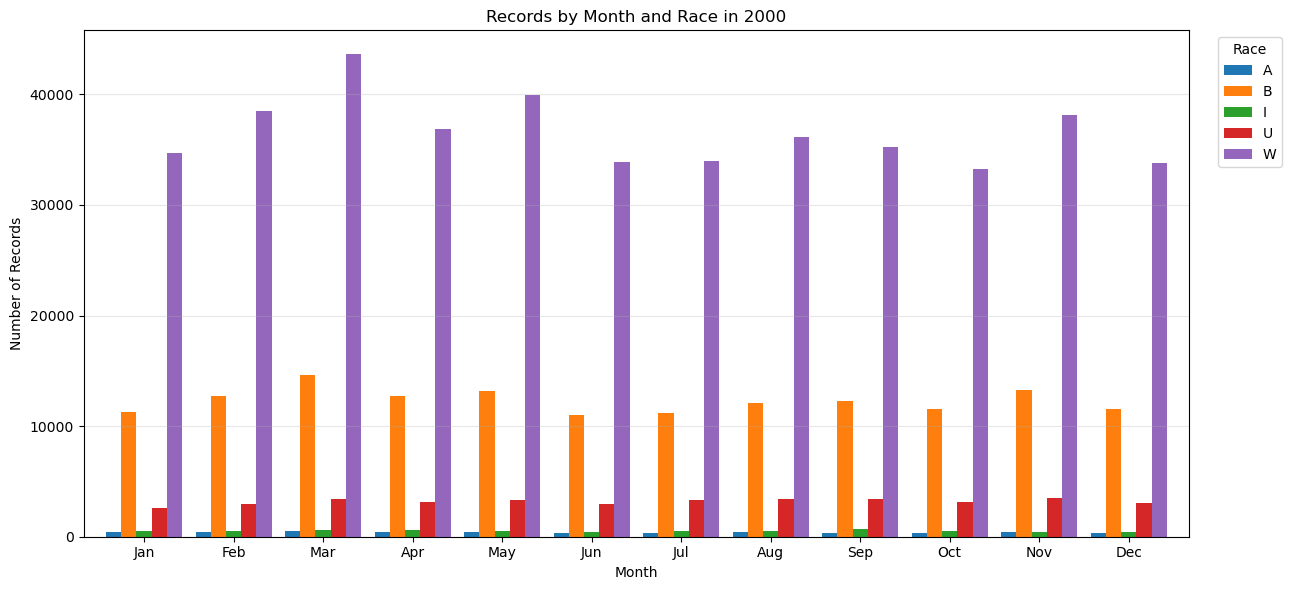

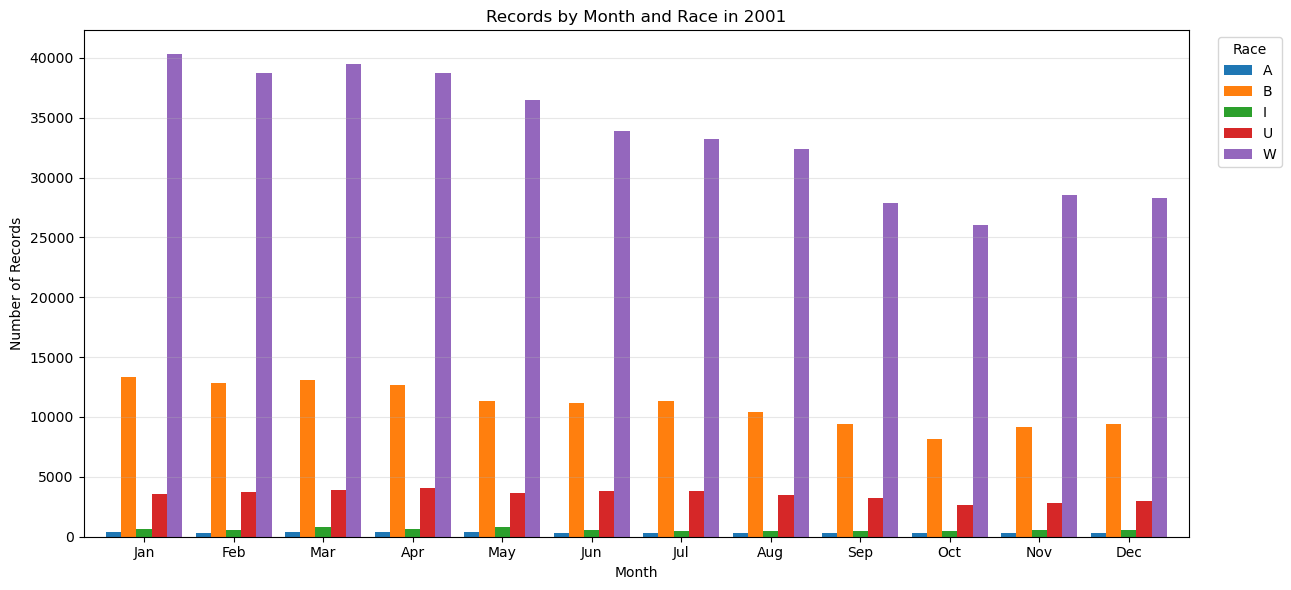

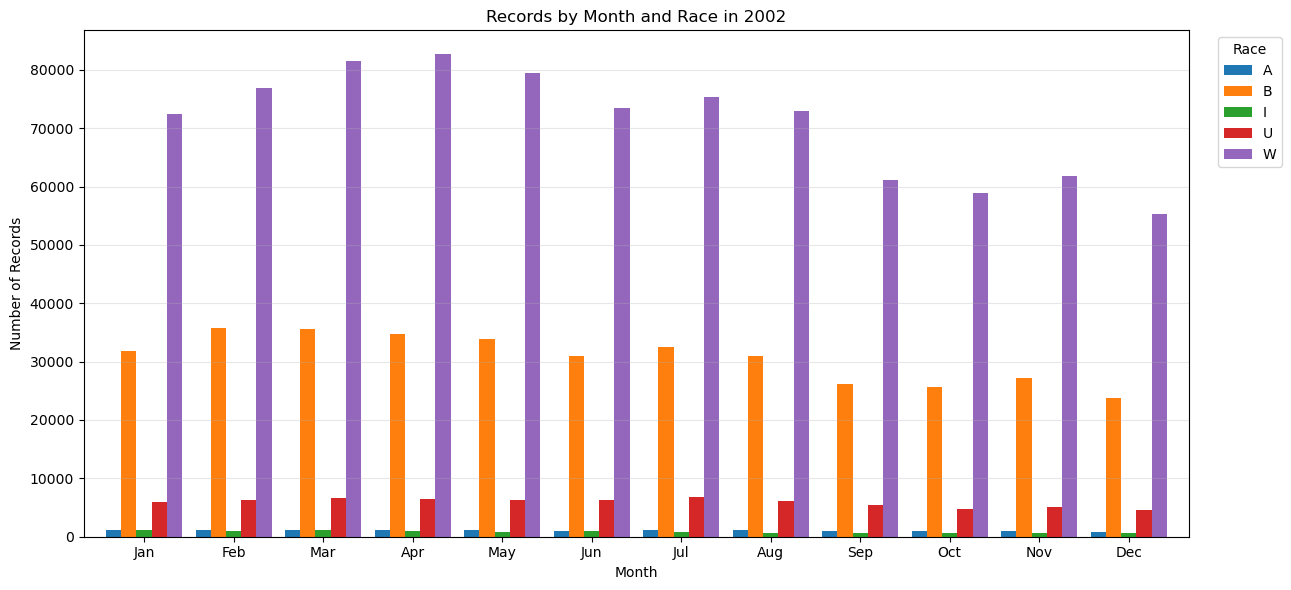

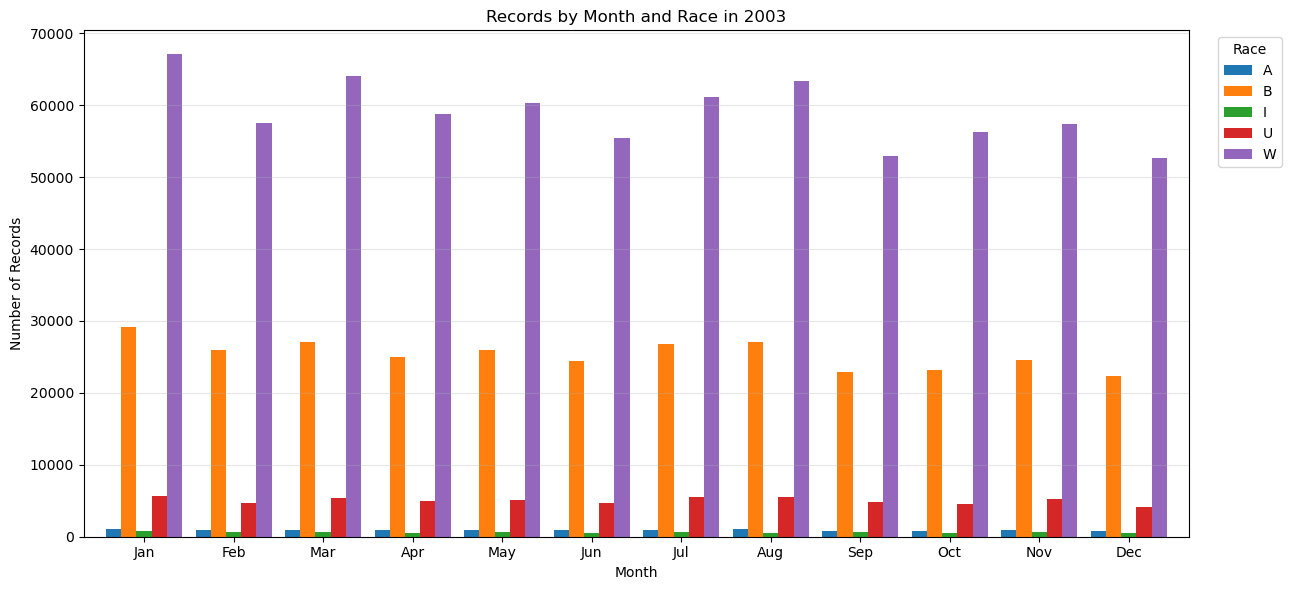

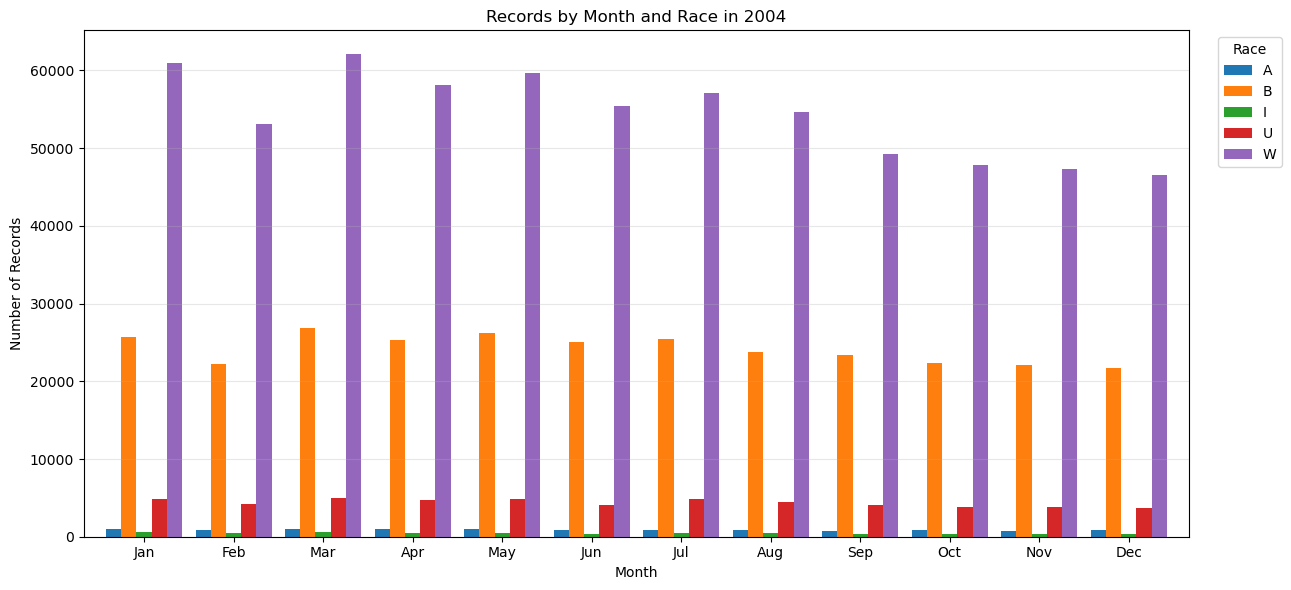

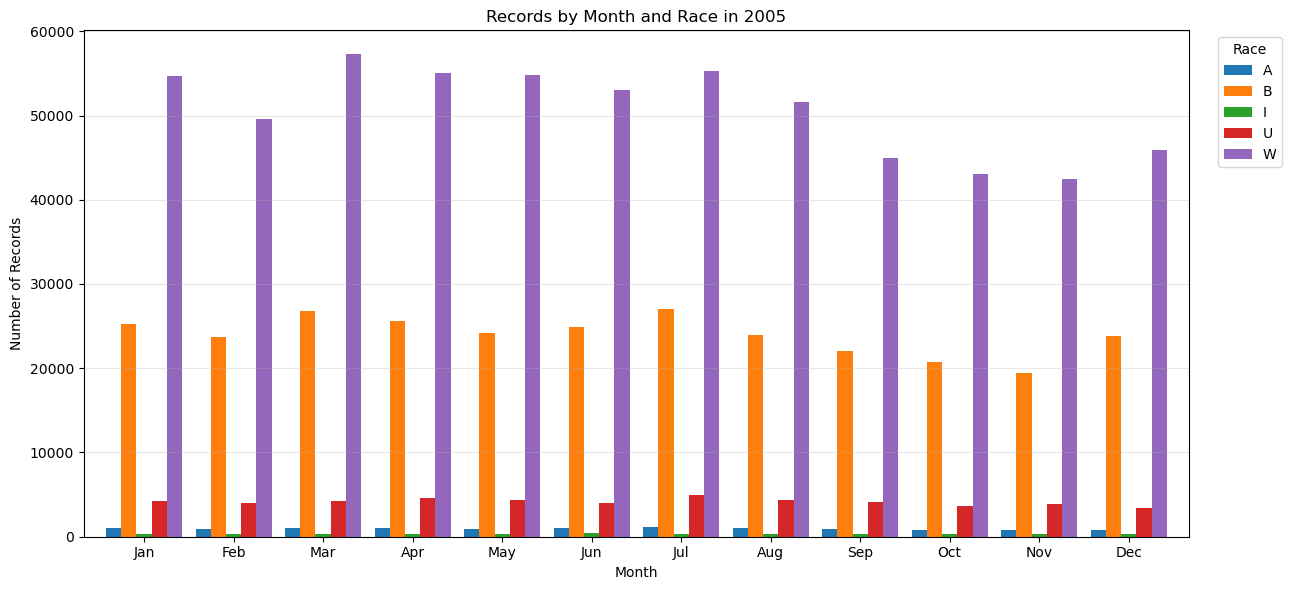

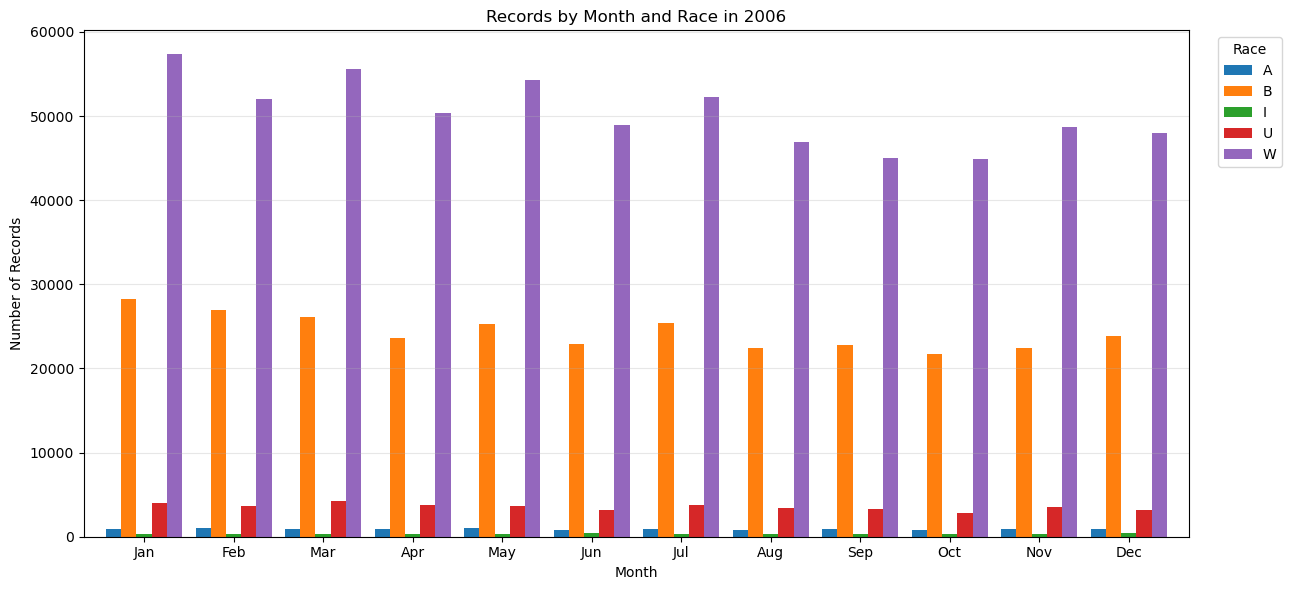

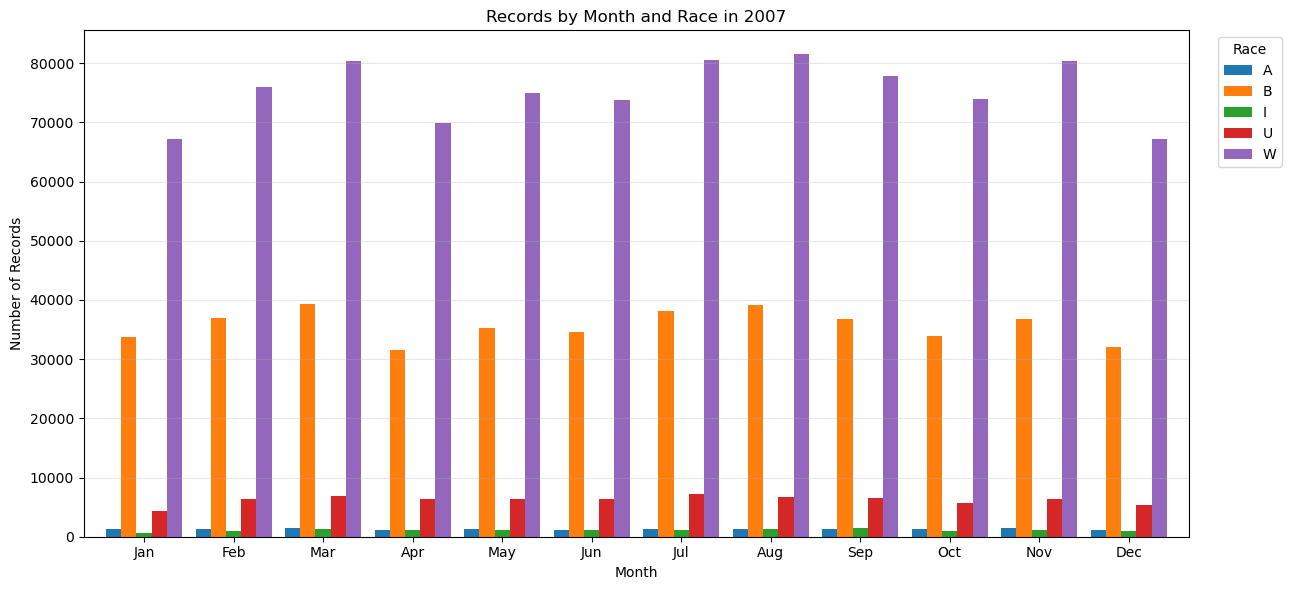

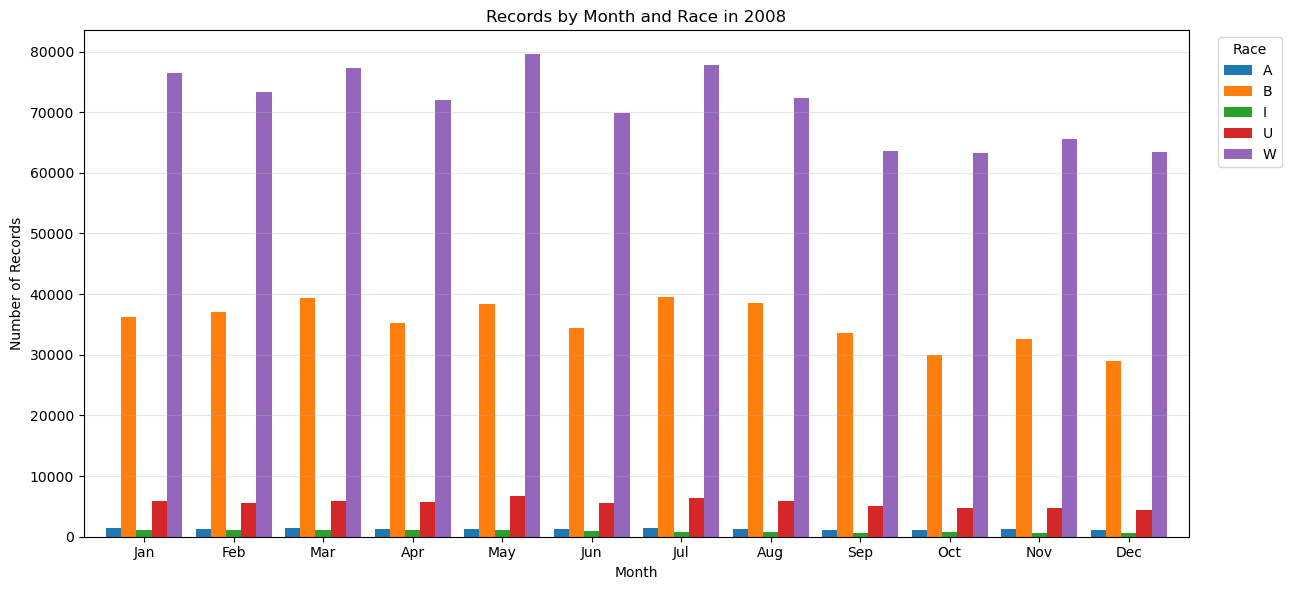

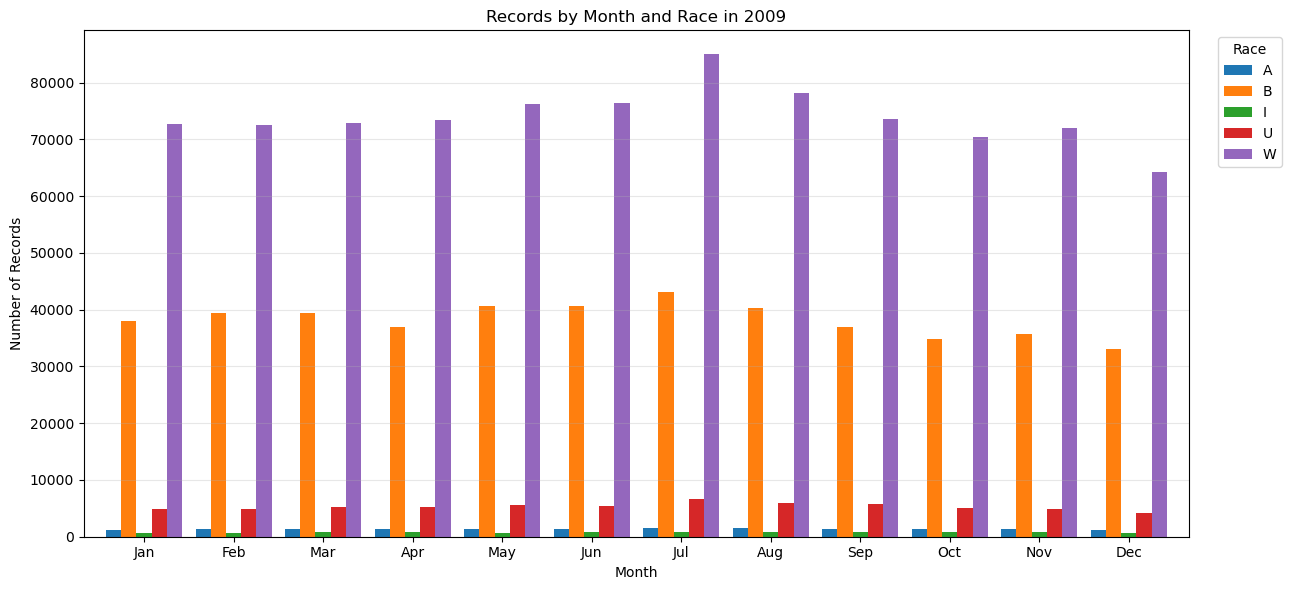

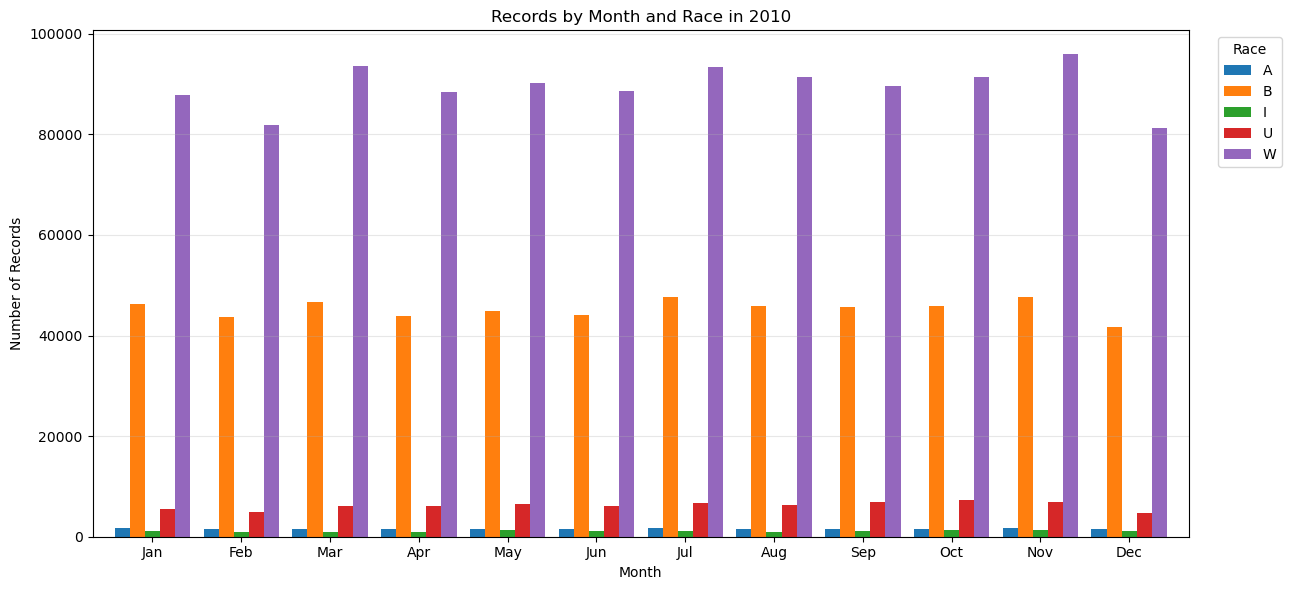

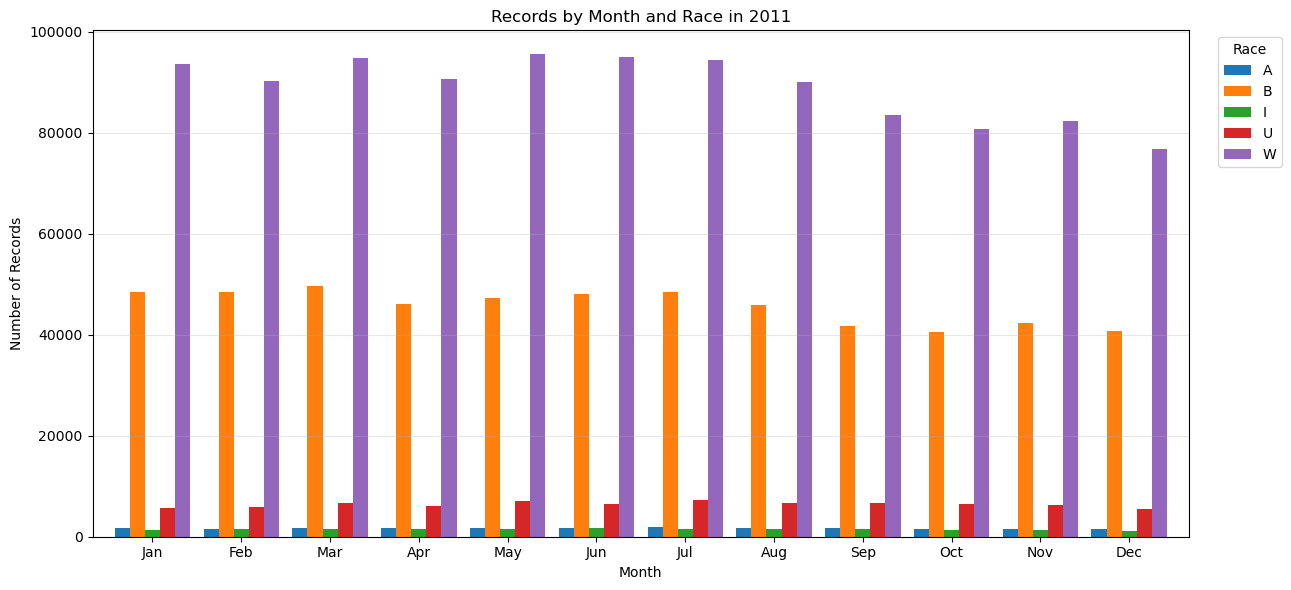

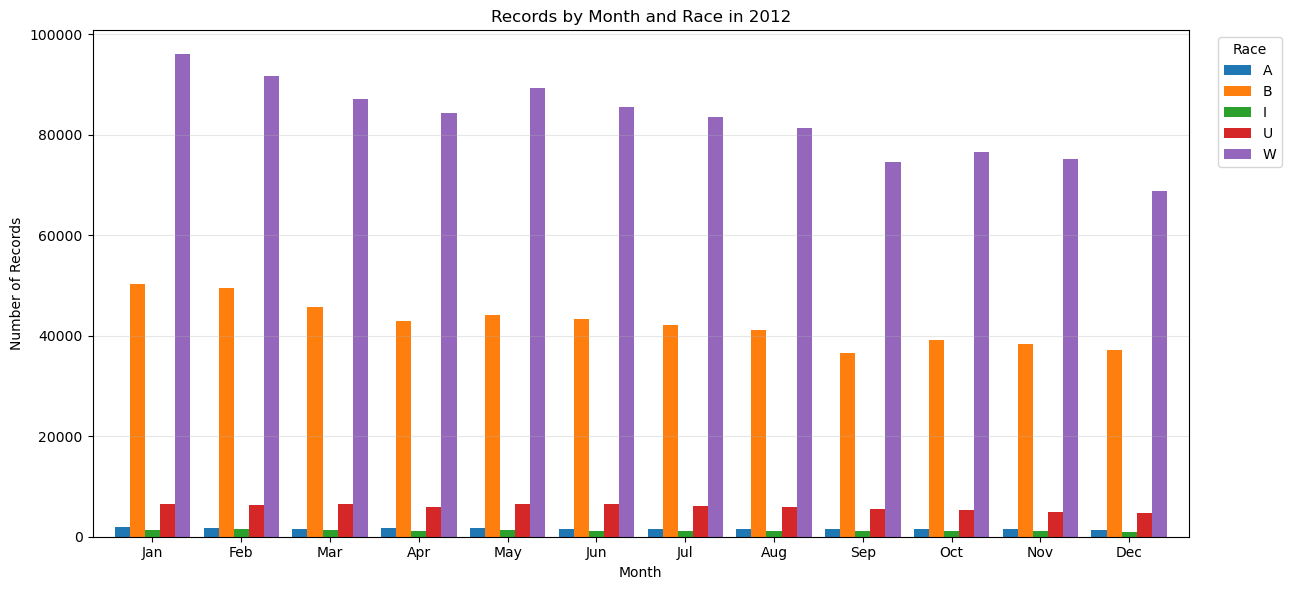

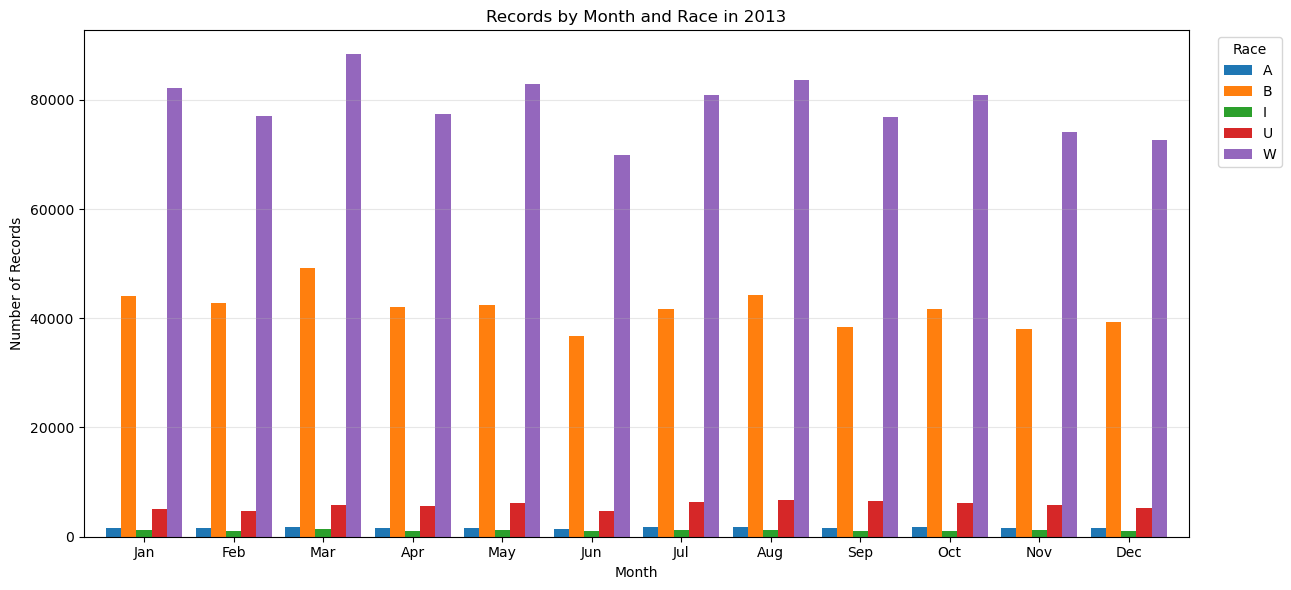

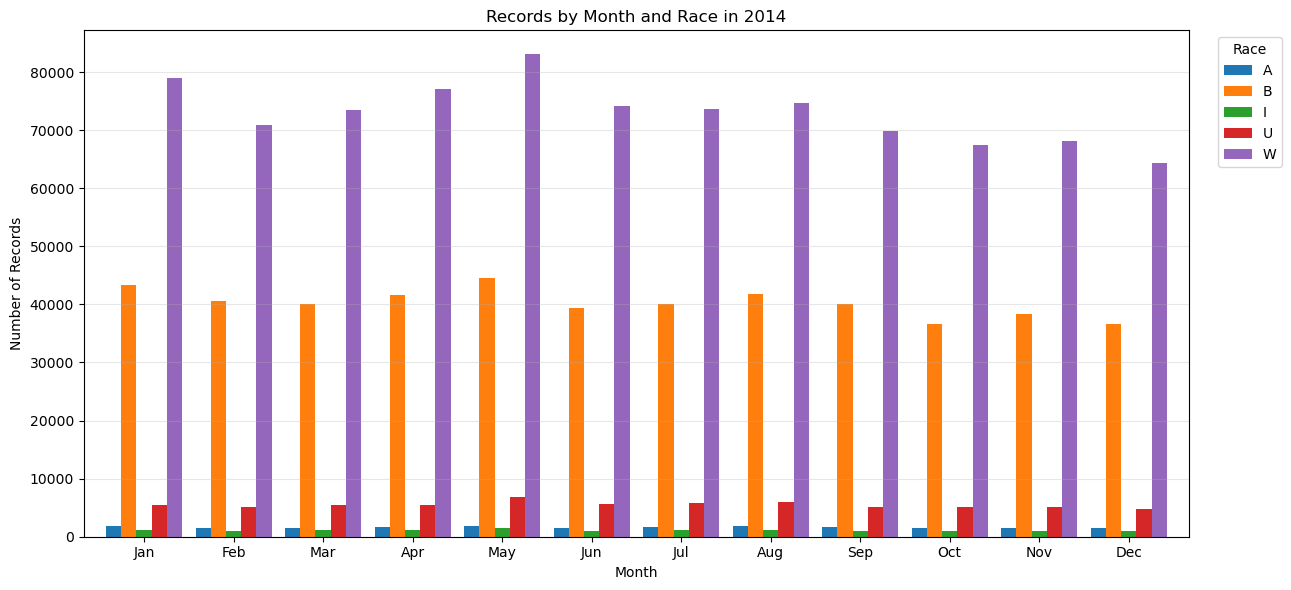

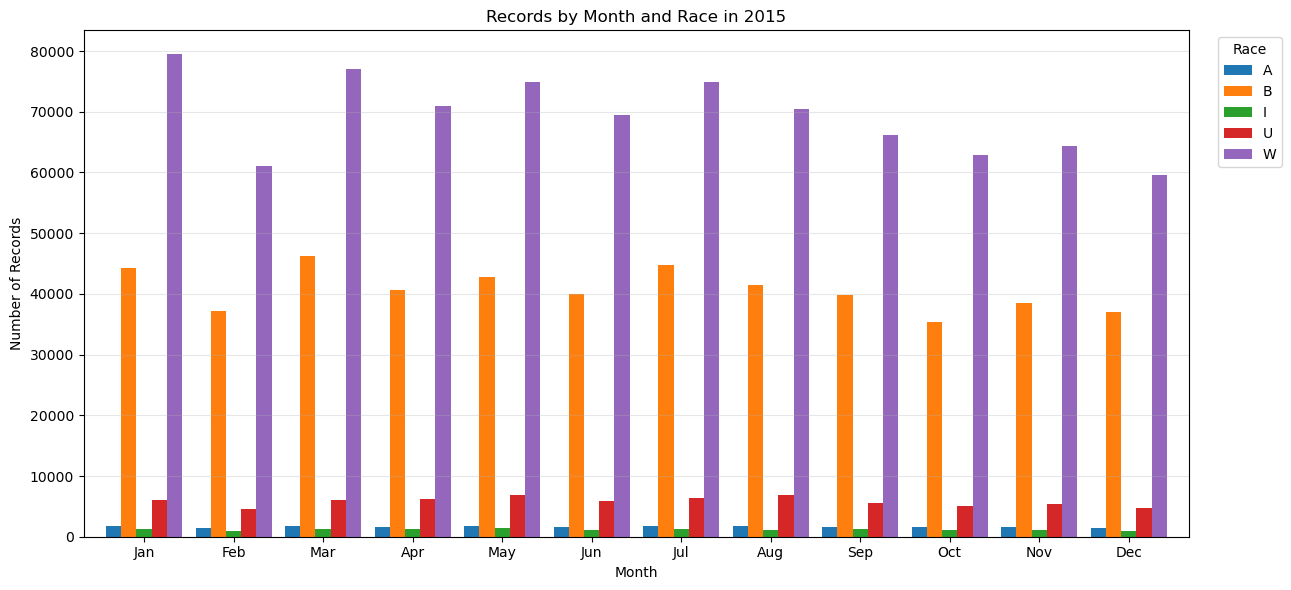

In [26]:
month_names = [
    "Jan", "Feb", "Mar", "Apr",
    "May", "Jun", "Jul", "Aug",
    "Sep", "Oct", "Nov", "Dec"
]


for year in sorted(monthly_by_race["year"].unique()):

    # Select one year.
    one_year = monthly_by_race[
        monthly_by_race["year"] == year
    ]

    # Reshape the table:
    # rows = months
    # columns = race categories
    # values = citation counts
    plot_data = one_year.pivot(
        index="month",
        columns="raw_Race",
        values="citation_count"
    )

    # Ensure all twelve months appear.
    plot_data = (
        plot_data
        .reindex(range(1, 13))
        .fillna(0)
    )

    plot_data.index = month_names

    ax = plot_data.plot(
        kind="bar",
        figsize=(13, 6),
        width=0.85
    )

    ax.set_title(f"Records by Month and Race in {year}")
    ax.set_xlabel("Month")
    ax.set_ylabel("Number of Records")
    ax.tick_params(axis="x", rotation=0)

    ax.legend(
        title="Race",
        bbox_to_anchor=(1.02, 1),
        loc="upper left"
    )

    ax.grid(axis="y", alpha=0.3)

    plt.tight_layout()
    plt.show()

In [32]:
all_columns = pd.read_csv(
    "Downloads/nc_statewide_2020_04_01.csv",
    nrows=0
).columns

print([
    column
    for column in all_columns
    if "citation" in column.lower()
])

['citation_issued']


In [34]:
monthly_by_race = (
    comparison
    .groupby(["year", "month", "raw_Race"])
    .size()
    .reset_index(name="citation_count")
)


# ------------------------------------------------------------
# STEP 2: Keep only White and Black categories.
#
# Based on your data:
# W = White
# B = Black
# ------------------------------------------------------------
white_black = monthly_by_race[
    monthly_by_race["raw_Race"].isin(["W", "B"])
].copy()


# ------------------------------------------------------------
# STEP 3: Reshape the data.
#
# After pivoting, each row represents one year-month pair,
# with separate columns for White and Black citation counts.
# ------------------------------------------------------------
white_black_wide = white_black.pivot_table(
    index=["year", "month"],
    columns="raw_Race",
    values="citation_count",
    fill_value=0
).reset_index()

# Rename the race-code columns so the later code is easier to read.
white_black_wide = white_black_wide.rename(
    columns={
        "W": "white_count",
        "B": "black_count"
    }
)


# ------------------------------------------------------------
# STEP 4: Calculate the White-to-Black ratio.
#
# A ratio of:
# 3 means 3 White records per 1 Black record.
# 2 means 2 White records per 1 Black record.
#
# replace(0, pd.NA) prevents division by zero if a month
# has no Black records.
# ------------------------------------------------------------
white_black_wide["white_black_ratio"] = (
    white_black_wide["white_count"]
    / white_black_wide["black_count"].replace(0, pd.NA)
)


# Inspect the results.
print(
    white_black_wide[
        ["year", "month", "white_count", "black_count", "white_black_ratio"]
    ].head(20)
)

# Total White-plus-Black citation records in each month.
white_black_wide["white_black_total"] = (
    white_black_wide["white_count"]
    + white_black_wide["black_count"]
)


# Percentage of those records coded White.
white_black_wide["white_percentage"] = (
    white_black_wide["white_count"]
    / white_black_wide["white_black_total"]
    * 100
)


# Percentage of those records coded Black.
white_black_wide["black_percentage"] = (
    white_black_wide["black_count"]
    / white_black_wide["white_black_total"]
    * 100
)

raw_Race  year  month  white_count  black_count  white_black_ratio
0         2000      1      34725.0      11251.0           3.086392
1         2000      2      38524.0      12762.0           3.018649
2         2000      3      43611.0      14592.0           2.988692
3         2000      4      36832.0      12690.0           2.902443
4         2000      5      39917.0      13140.0           3.037823
5         2000      6      33844.0      10999.0           3.077007
6         2000      7      34013.0      11184.0           3.041220
7         2000      8      36143.0      12047.0           3.000166
8         2000      9      35277.0      12312.0           2.865253
9         2000     10      33283.0      11587.0           2.872443
10        2000     11      38166.0      13303.0           2.868977
11        2000     12      33830.0      11530.0           2.934085
12        2001      1      40280.0      13367.0           3.013391
13        2001      2      38698.0      12852.0           3.01

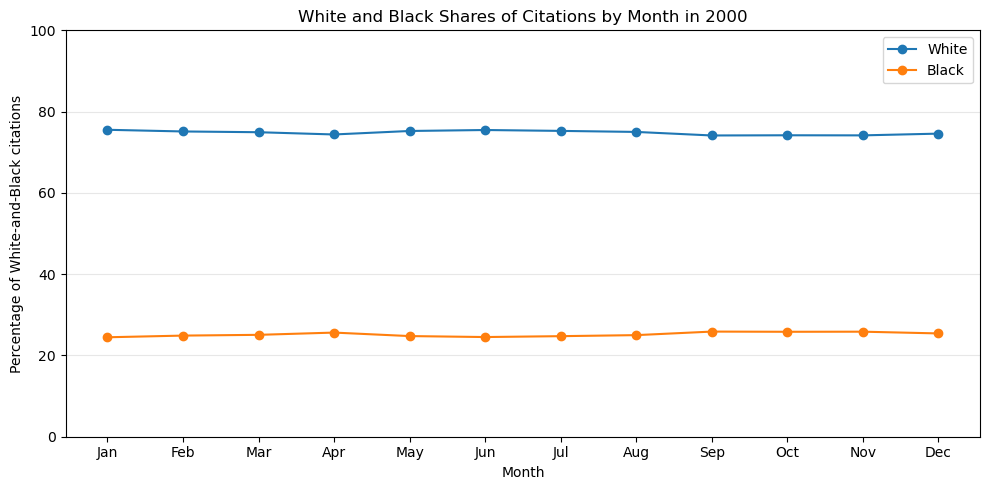

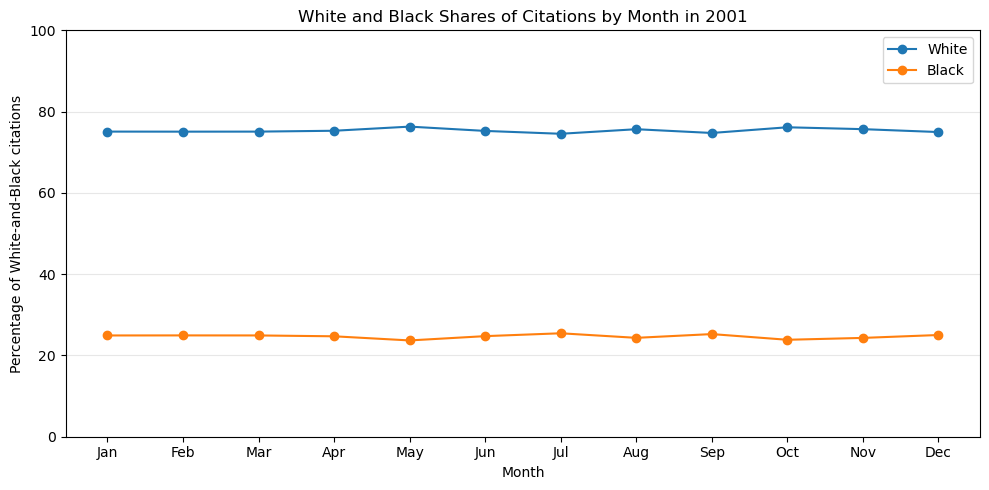

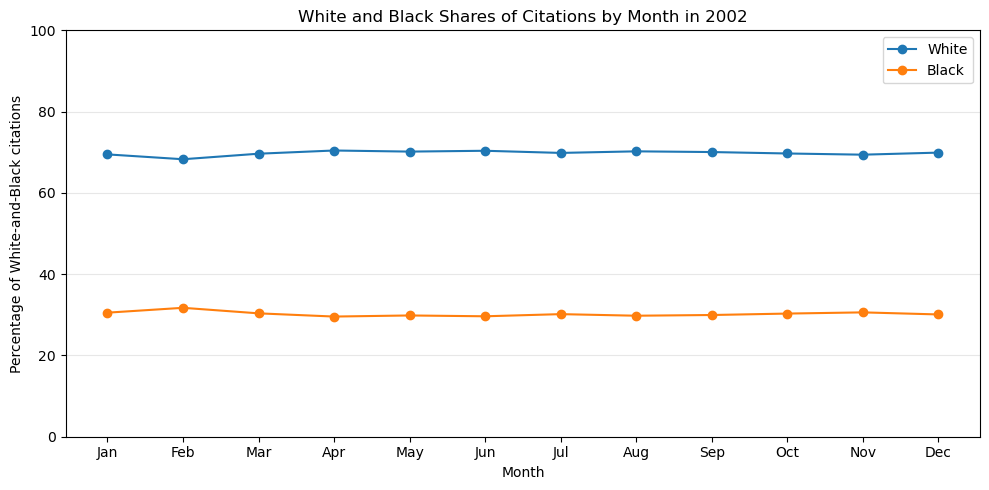

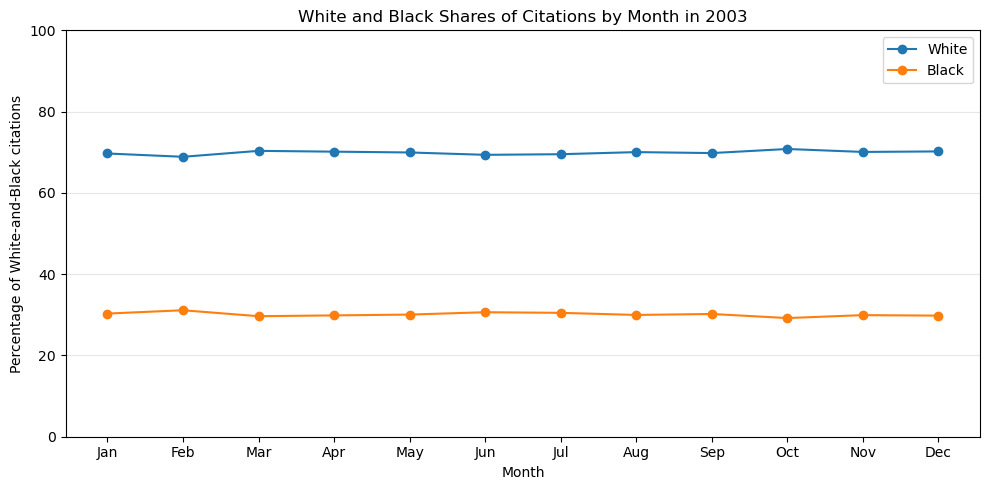

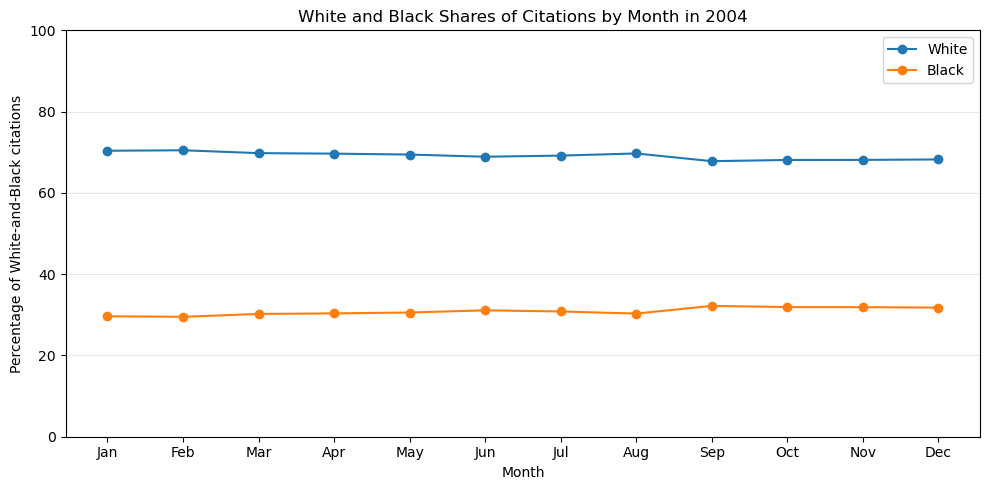

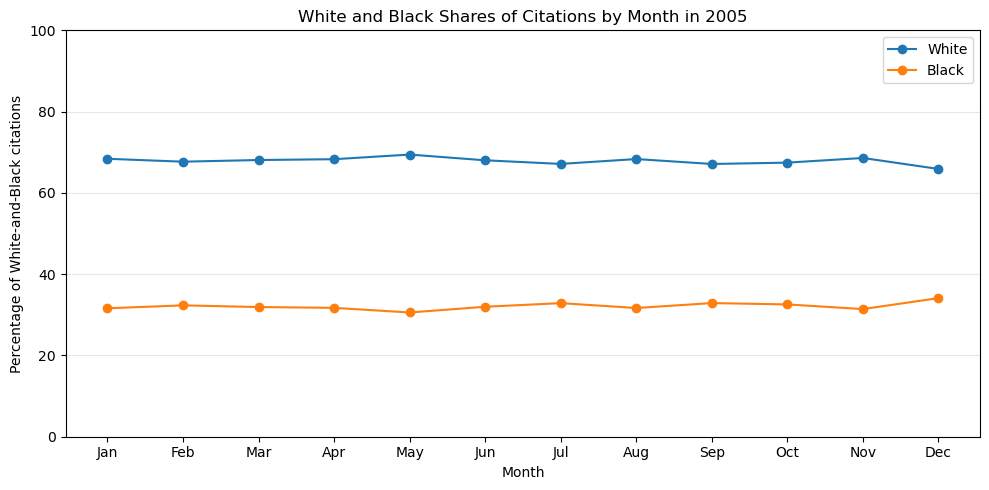

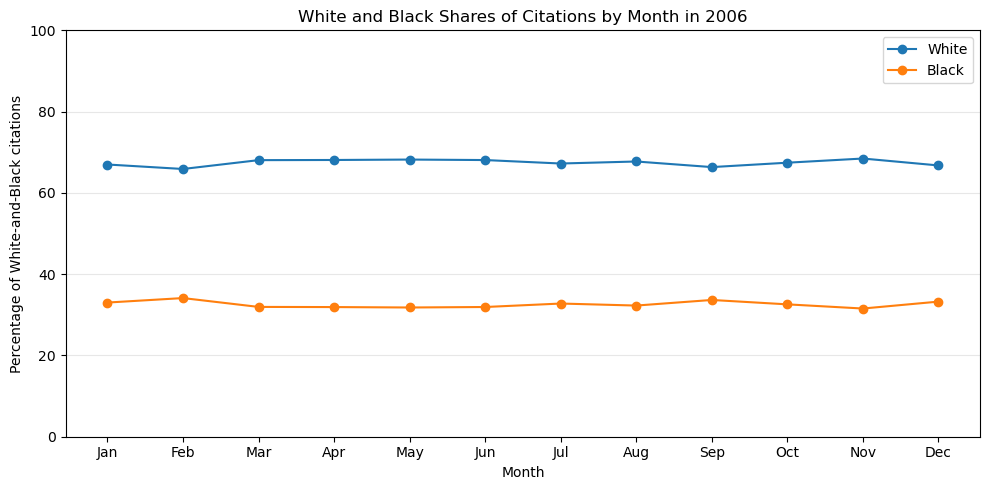

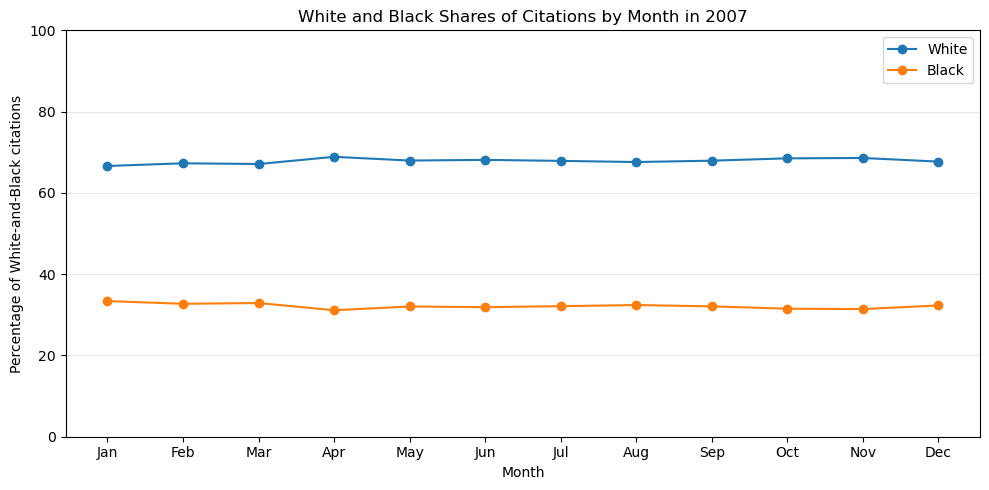

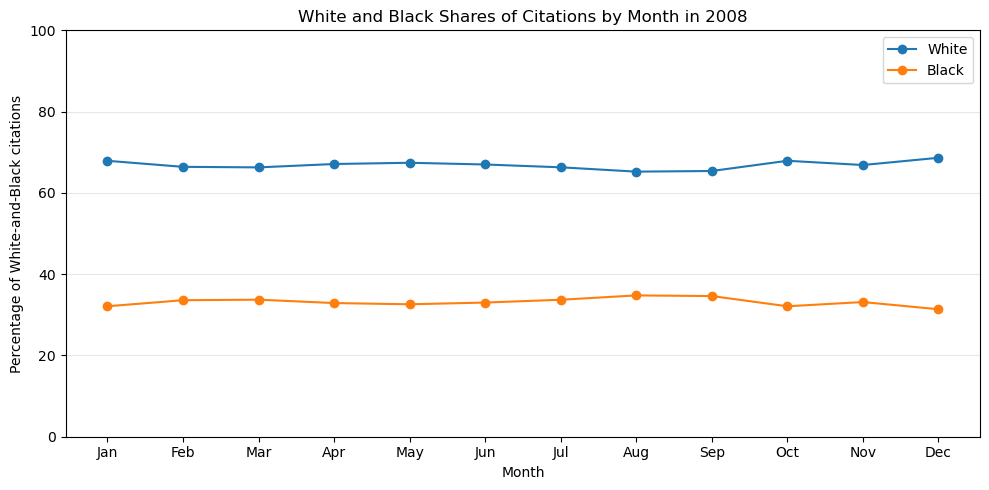

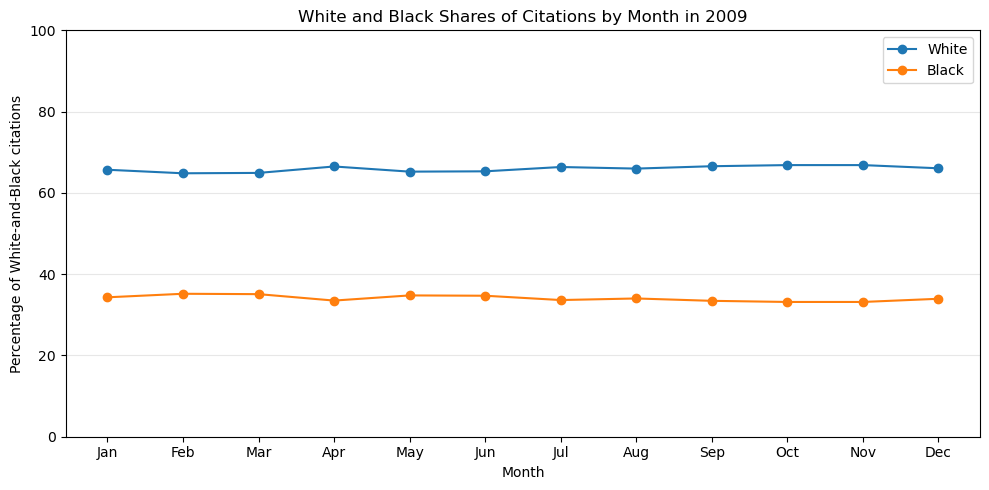

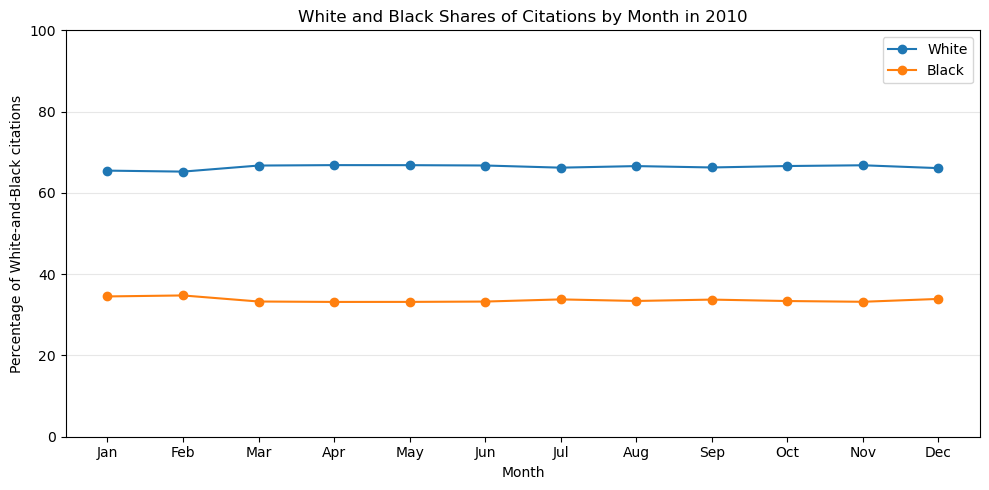

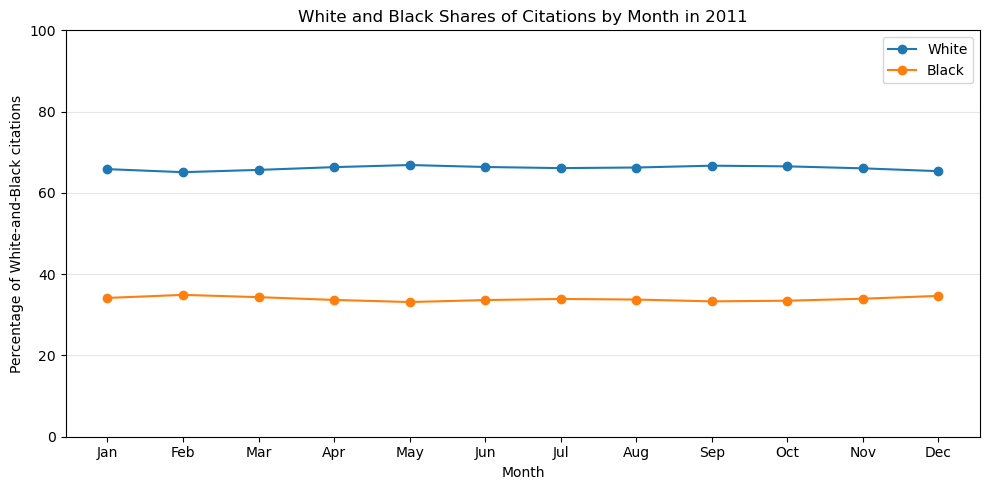

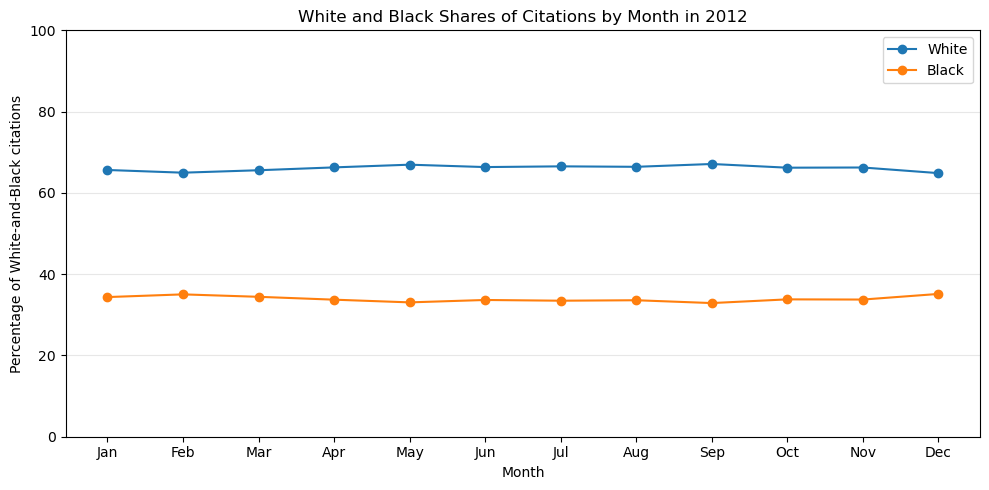

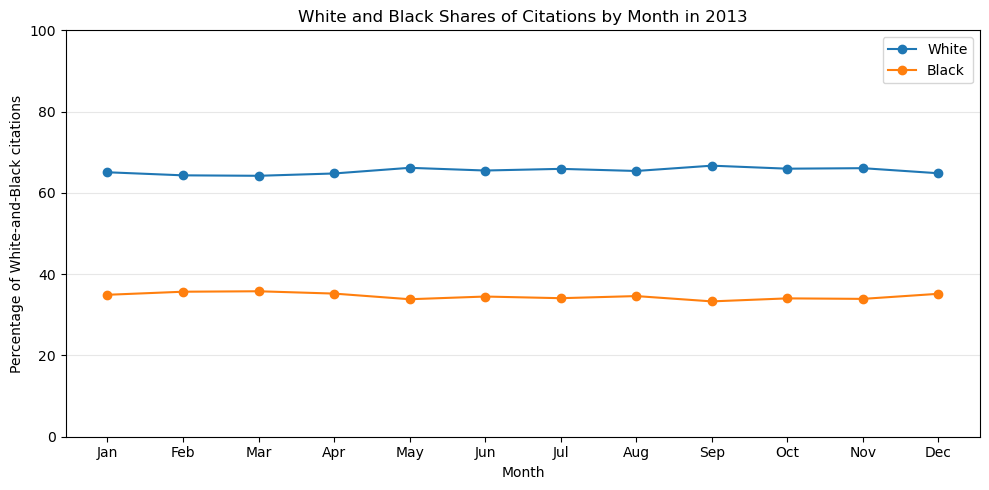

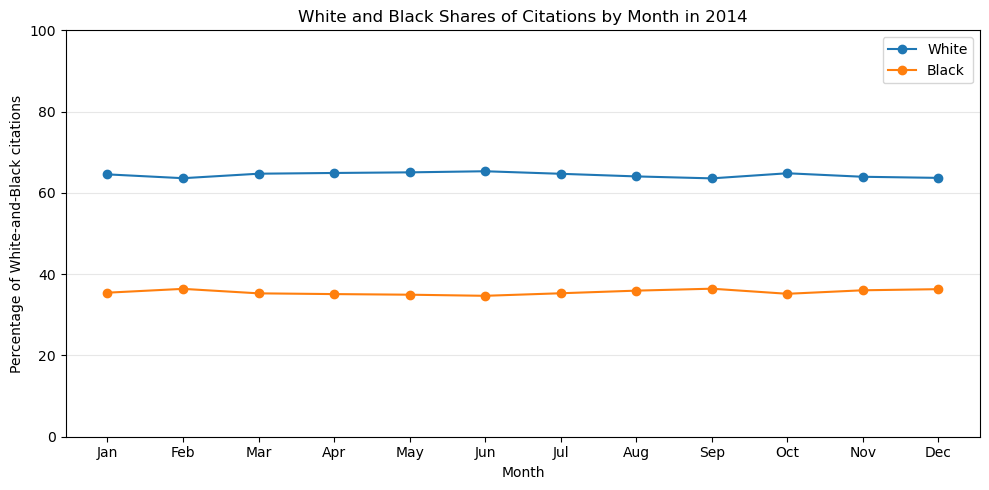

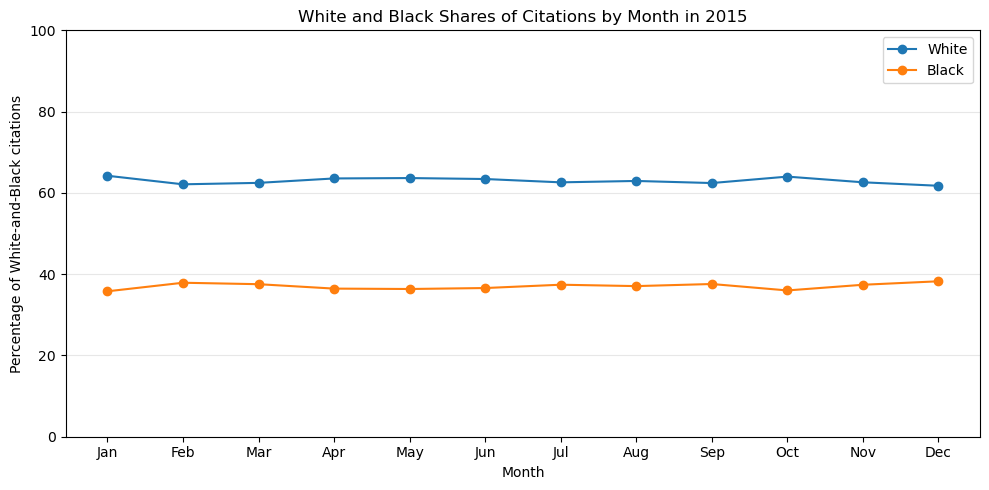

In [35]:
for year in sorted(white_black_wide["year"].unique()):

    one_year = (
        white_black_wide[
            white_black_wide["year"] == year
        ]
        .set_index("month")
        .reindex(range(1, 13))
    )

    plt.figure(figsize=(10, 5))

    plt.plot(
        month_names,
        one_year["white_percentage"],
        marker="o",
        label="White"
    )

    plt.plot(
        month_names,
        one_year["black_percentage"],
        marker="o",
        label="Black"
    )

    plt.title(f"White and Black Shares of Citations by Month in {year}")
    plt.xlabel("Month")
    plt.ylabel("Percentage of White-and-Black citations")

    plt.ylim(0, 100)
    plt.grid(axis="y", alpha=0.3)
    plt.legend()
    plt.tight_layout()
    plt.show()

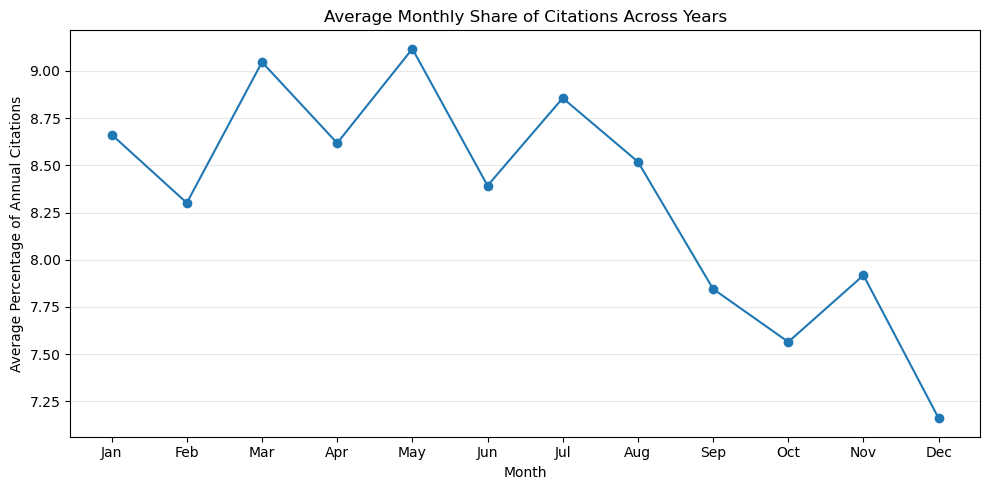

In [36]:
import matplotlib.pyplot as plt

month_names = [
    "Jan", "Feb", "Mar", "Apr",
    "May", "Jun", "Jul", "Aug",
    "Sep", "Oct", "Nov", "Dec"
]

plt.figure(figsize=(10, 5))

plt.plot(
    month_names,
    average_monthly_pattern.values,
    marker="o"
)

plt.title("Average Monthly Share of Citations Across Years")
plt.xlabel("Month")
plt.ylabel("Average Percentage of Annual Citations")

plt.grid(axis="y", alpha=0.3)
plt.tight_layout()
plt.show()

In [37]:
print(average_monthly_pattern.sum())

100.0


In [39]:
import matplotlib.pyplot as plt

monthly_summary = (
    monthly_counts_complete
    .groupby("month")["monthly_percentage"]
    .agg(
        average_percentage="mean",
        standard_deviation="std",
        number_of_years="count"
    )
    .reindex(range(1, 13))
)

month_names = [
    "Jan", "Feb", "Mar", "Apr",
    "May", "Jun", "Jul", "Aug",
    "Sep", "Oct", "Nov", "Dec"
]

monthly_summary.index = month_names

monthly_summary

plt.figure(figsize=(10, 5))

plt.errorbar(
    monthly_summary.index,
    monthly_summary["average_percentage"],
    yerr=monthly_summary["standard_deviation"],
    marker="o",
    capsize=4
)

plt.axhline(
    y=100 / 12,
    linestyle="--",
    label="Even monthly share"
)

plt.title("Average Percent of Annual Citations by Month")
plt.xlabel("Month")
plt.ylabel("Average Percentage of Annual Citations")

plt.grid(axis="y", alpha=0.3)
plt.legend()
plt.tight_layout()
plt.show()

NameError: name 'monthly_counts_complete' is not defined

In [40]:
monthly_counts = (
    comparison
    .groupby(["year", "month"])
    .size()
    .reset_index(name="monthly_citations")
)

# ------------------------------------------------------------
# STEP 5: Keep only complete years.
#
# A complete year has all 12 months represented.
# This avoids distorting the normalized percentages.
# ------------------------------------------------------------
months_per_year = (
    monthly_counts
    .groupby("year")["month"]
    .nunique()
)

complete_years = months_per_year[
    months_per_year == 12
].index

monthly_counts_complete = monthly_counts[
    monthly_counts["year"].isin(complete_years)
].copy()

# ------------------------------------------------------------
# STEP 6: Compute yearly totals.
# ------------------------------------------------------------
monthly_counts_complete["yearly_citations"] = (
    monthly_counts_complete
    .groupby("year")["monthly_citations"]
    .transform("sum")
)

# ------------------------------------------------------------
# STEP 7: Normalize each month by that year's total.
#
# This gives the percentage of that year's citations that occurred
# in each month.
# ------------------------------------------------------------
monthly_counts_complete["monthly_percentage"] = (
    monthly_counts_complete["monthly_citations"]
    / monthly_counts_complete["yearly_citations"]
    * 100
)

# Check that each complete year sums to about 100%.
check = (
    monthly_counts_complete
    .groupby("year")["monthly_percentage"]
    .sum()
)

print(check.head())

year
2000    100.0
2001    100.0
2002    100.0
2003    100.0
2004    100.0
Name: monthly_percentage, dtype: float64


In [41]:
month_names = [
    "Jan", "Feb", "Mar", "Apr",
    "May", "Jun", "Jul", "Aug",
    "Sep", "Oct", "Nov", "Dec"
]

monthly_summary = (
    monthly_counts_complete
    .groupby("month")["monthly_percentage"]
    .agg(
        average_percentage="mean",
        standard_deviation="std",
        number_of_years="count"
    )
    .reindex(range(1, 13))
)

monthly_summary.index = month_names

monthly_summary

,average_percentage,standard_deviation,number_of_years
Jan,8.847085,0.683829,16
Feb,8.465518,0.573500,16
Mar,9.135336,0.458734,16
Apr,8.556812,0.507400,16
May,8.876827,0.319719,16
Jun,8.274464,0.402040,16
Jul,8.748972,0.420647,16
Aug,8.493372,0.349995,16
Sep,7.813326,0.452788,16
Oct,7.585158,0.543514,16


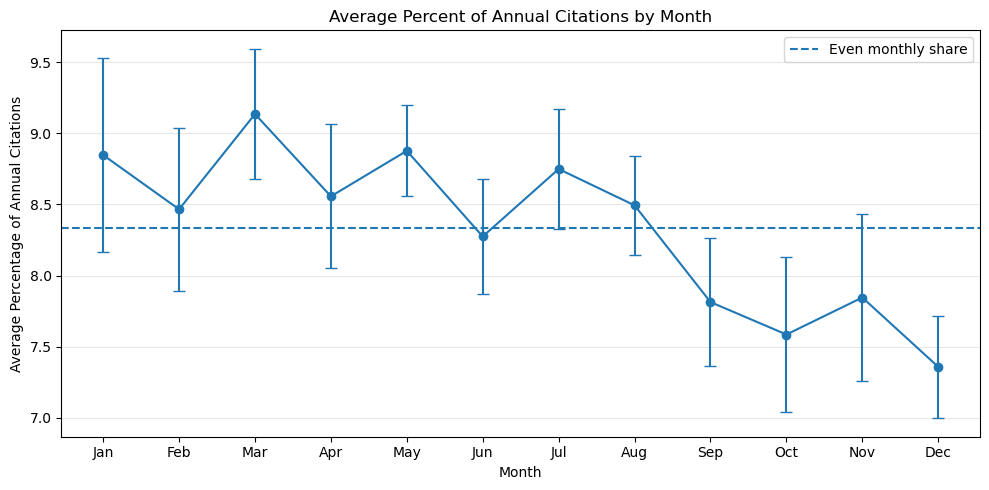

In [42]:
plt.figure(figsize=(10, 5))

plt.errorbar(
    monthly_summary.index,
    monthly_summary["average_percentage"],
    yerr=monthly_summary["standard_deviation"],
    marker="o",
    capsize=4
)

plt.axhline(
    y=100 / 12,
    linestyle="--",
    label="Even monthly share"
)

plt.title("Average Percent of Annual Citations by Month")
plt.xlabel("Month")
plt.ylabel("Average Percentage of Annual Citations")

plt.grid(axis="y", alpha=0.3)
plt.legend()
plt.tight_layout()
plt.show()

In [43]:
import pandas as pd
import matplotlib.pyplot as plt

df = pd.read_csv(
    "Downloads/nc_statewide_2020_04_01.csv",
    usecols=["raw_Race", "citation_issued", "warning_issued"],
    dtype="string"
)

In [44]:
print(df["raw_Race"].value_counts(dropna=False).head(20))

print(df["citation_issued"].value_counts(dropna=False).head(20))

print(df["warning_issued"].value_counts(dropna=False).head(20))

raw_Race
W       12698580
B        6207569
U         986905
A         230178
I         163395
<NA>          18
Name: count, dtype: Int64
citation_issued
TRUE     13406566
FALSE     6880079
Name: count, dtype: Int64
warning_issued
FALSE    14437490
TRUE      5849155
Name: count, dtype: Int64


In [45]:
analysis_df = df.copy()

analysis_df["raw_Race"] = analysis_df["raw_Race"].str.strip()

analysis_df = analysis_df.dropna(subset=["raw_Race"])

analysis_df = analysis_df[
    analysis_df["raw_Race"] != ""
].copy()

In [46]:
analysis_df = analysis_df[
    analysis_df["raw_Race"].isin(["W", "B"])
].copy()

In [47]:
def to_boolean_outcome(column):
    """
    Convert common yes/no encodings into True/False.

    True means the outcome happened.
    False means the outcome did not happen.
    Missing or unclear values become <NA>.
    """

    cleaned = column.astype("string").str.strip().str.lower()

    return cleaned.map({
        "true": True,
        "false": False,
        "yes": True,
        "no": False,
        "y": True,
        "n": False,
        "1": True,
        "0": False,
        "t": True,
        "f": False
    })

In [48]:
analysis_df["citation_bool"] = to_boolean_outcome(
    analysis_df["citation_issued"]
)

analysis_df["warning_bool"] = to_boolean_outcome(
    analysis_df["warning_issued"]
)

In [49]:
print(analysis_df["citation_bool"].value_counts(dropna=False))
print(analysis_df["warning_bool"].value_counts(dropna=False))

citation_bool
True     12355951
False     6550198
Name: count, dtype: int64
warning_bool
False    13326408
True      5579741
Name: count, dtype: int64


In [50]:
analysis_df = analysis_df.dropna(
    subset=["citation_bool", "warning_bool"],
    how="all"
).copy()

In [51]:
race_outcome_summary = (
    analysis_df
    .groupby("raw_Race")
    .agg(
        total_stops=("raw_Race", "size"),
        citation_rate=("citation_bool", "mean"),
        warning_rate=("warning_bool", "mean"),
        citation_count=("citation_bool", "sum"),
        warning_count=("warning_bool", "sum")
    )
)

race_outcome_summary["citation_rate_percent"] = (
    race_outcome_summary["citation_rate"] * 100
)

race_outcome_summary["warning_rate_percent"] = (
    race_outcome_summary["warning_rate"] * 100
)

race_outcome_summary

,total_stops,citation_rate,warning_rate,citation_count,warning_count,citation_rate_percent,warning_rate_percent
raw_Race,,,,,,,
B,6207569,0.628191,0.312680,3899542,1940983,62.819149,31.268005
W,12698580,0.665933,0.286548,8456409,3638758,66.593344,28.654842


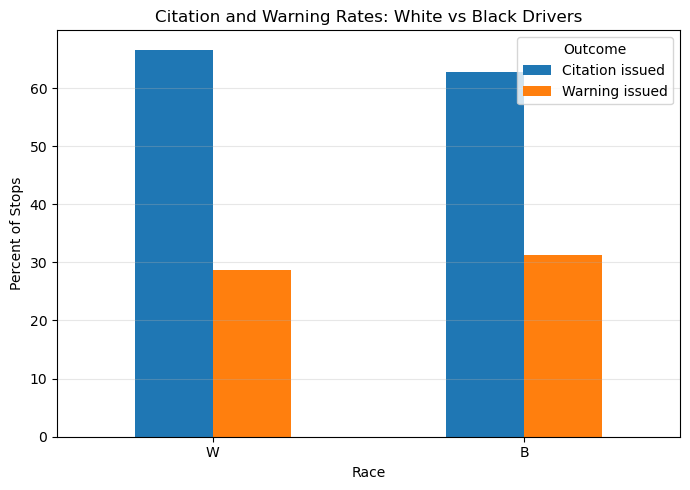

In [52]:
white_black_summary = race_outcome_summary.loc[["W", "B"]]

white_black_summary[
    ["citation_rate_percent", "warning_rate_percent", "total_stops"]
]

plot_data = white_black_summary[
    ["citation_rate_percent", "warning_rate_percent"]
]

ax = plot_data.plot(
    kind="bar",
    figsize=(7, 5)
)

ax.set_title("Citation and Warning Rates: White vs Black Drivers")
ax.set_xlabel("Race")
ax.set_ylabel("Percent of Stops")
ax.tick_params(axis="x", rotation=0)

ax.legend(
    ["Citation issued", "Warning issued"],
    title="Outcome"
)

ax.grid(axis="y", alpha=0.3)

plt.tight_layout()
plt.show()

In [60]:
df = pd.read_csv(
    "Downloads/nc_statewide_2020_04_01.csv",
    usecols=[
        "subject_race",
        "reason_for_stop", 
        "outcome"
    ],
    dtype="string"
)

In [61]:
for col in ["subject_race", "reason_for_stop", "outcome"]:
    print("\n", col)
    print(df[col].value_counts(dropna=False).head(20))


 subject_race
subject_race
white                     11893673
black                      6187854
hispanic                   1576072
unknown                     242640
asian/pacific islander      225489
other                       160899
<NA>                            18
Name: count, dtype: Int64

 reason_for_stop
reason_for_stop
Speed Limit Violation            8501364
Vehicle Regulatory Violation     3320251
Seat Belt Violation              1869976
Vehicle Equipment Violation      1738641
Investigation                    1371729
Safe Movement Violation          1079276
Other Motor Vehicle Violation    1043409
Stop Light/Sign Violation         930169
Checkpoint                        238683
Driving While Impaired            193147
Name: count, dtype: Int64

 outcome
outcome
citation    13406566
warning      5849155
<NA>          605059
arrest        425865
Name: count, dtype: Int64


In [65]:
# ------------------------------------------------------------
# STEP 3: Clean text values.
#
# str.strip() removes accidental spaces.
# For example, "White" and " White " should be treated as the same.
# ------------------------------------------------------------
analysis_df = df.copy()

for col in ["subject_race", "reason_for_stop", "outcome"]:
    analysis_df[col] = analysis_df[col].astype("string").str.strip()

In [66]:
# ------------------------------------------------------------
# STEP 4: Remove rows missing race, stop reason, or outcome.
#
# Rows with missing outcome cannot tell us whether the person got
# a warning, citation, or arrest.
# ------------------------------------------------------------
analysis_df = analysis_df.dropna(
    subset=["subject_race", "reason_for_stop", "outcome"]
).copy()

# Remove empty strings too, since "" is not the same as pandas NA.
analysis_df = analysis_df[
    (analysis_df["subject_race"] != "")
    & (analysis_df["reason_for_stop"] != "")
    & (analysis_df["outcome"] != "")
].copy()

In [67]:
# ------------------------------------------------------------
# STEP 5: Focus on White and Black drivers.
#
# You can remove this filter later if you want to compare all races.
# ------------------------------------------------------------
analysis_df = analysis_df[
    analysis_df["subject_race"].isin(["white", "black"])
].copy()

In [68]:
# ------------------------------------------------------------
# STEP 6: Count outcomes by race.
#
# This gives the number of warnings, citations, arrests, etc.
# for each race group.
# ------------------------------------------------------------
race_outcome_counts = (
    analysis_df
    .groupby(["subject_race", "outcome"])
    .size()
    .reset_index(name="count")
)

race_outcome_counts

,subject_race,outcome,count
0,black,arrest,160741
1,black,citation,3887760
2,black,warning,1934615
3,white,arrest,196395
4,white,citation,7941106
5,white,warning,3408984


In [69]:
# ------------------------------------------------------------
# STEP 7: Convert counts to within-race percentages.
#
# This answers:
# Among White drivers, what percent got warnings/citations/arrests?
# Among Black drivers, what percent got warnings/citations/arrests?
#
# This is better than raw counts because the race groups may have
# different total numbers of stops.
# ------------------------------------------------------------
race_outcome_counts["race_total"] = (
    race_outcome_counts
    .groupby("subject_race")["count"]
    .transform("sum")
)

race_outcome_counts["percent"] = (
    race_outcome_counts["count"]
    / race_outcome_counts["race_total"]
    * 100
)

race_outcome_counts

,subject_race,outcome,count,race_total,percent
0,black,arrest,160741,5983116,2.686577
1,black,citation,3887760,5983116,64.978850
2,black,warning,1934615,5983116,32.334573
3,white,arrest,196395,11546485,1.700907
4,white,citation,7941106,11546485,68.775095
5,white,warning,3408984,11546485,29.523998


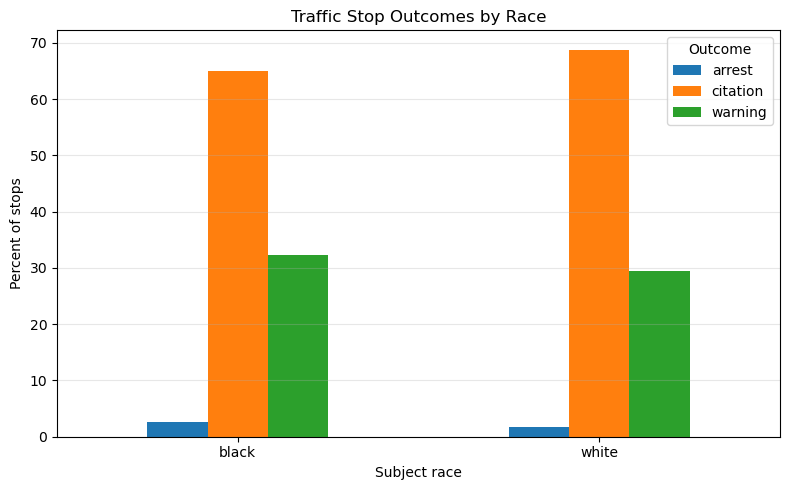

In [70]:
# ------------------------------------------------------------
# STEP 8: Reshape for plotting.
#
# Rows become races.
# Columns become outcomes.
# Values are percentages.
# ------------------------------------------------------------
plot_data = race_outcome_counts.pivot(
    index="subject_race",
    columns="outcome",
    values="percent"
).fillna(0)

ax = plot_data.plot(
    kind="bar",
    figsize=(8, 5)
)

ax.set_title("Traffic Stop Outcomes by Race")
ax.set_xlabel("Subject race")
ax.set_ylabel("Percent of stops")
ax.tick_params(axis="x", rotation=0)

ax.legend(title="Outcome")
ax.grid(axis="y", alpha=0.3)

plt.tight_layout()
plt.show()

In [71]:
# ------------------------------------------------------------
# STEP 9: Count outcomes by stop reason, race, and outcome.
#
# This lets us compare White and Black drivers within similar
# categories of stops.
# ------------------------------------------------------------
by_reason = (
    analysis_df
    .groupby(["reason_for_stop", "subject_race", "outcome"])
    .size()
    .reset_index(name="count")
)

# Compute total stops within each stop_reason/race pair.
by_reason["reason_race_total"] = (
    by_reason
    .groupby(["reason_for_stop", "subject_race"])["count"]
    .transform("sum")
)

# Compute outcome percentages within each stop_reason/race pair.
by_reason["percent"] = (
    by_reason["count"]
    / by_reason["reason_race_total"]
    * 100
)

by_reason.head(20)

,reason_for_stop,subject_race,outcome,count,reason_race_total,percent
0,Checkpoint,black,arrest,2854,61280,4.657311
1,Checkpoint,black,citation,51542,61280,84.109008
2,Checkpoint,black,warning,6884,61280,11.233681
3,Checkpoint,white,arrest,4064,90464,4.492395
4,Checkpoint,white,citation,71722,90464,79.282366
5,Checkpoint,white,warning,14678,90464,16.225239
6,Driving While Impaired,black,arrest,21030,39571,53.144980
7,Driving While Impaired,black,citation,12000,39571,30.325238
8,Driving While Impaired,black,warning,6541,39571,16.529782
9,Driving While Impaired,white,arrest,60415,101256,59.665600


In [72]:
# ------------------------------------------------------------
# STEP 10: Pull out citation rates only.
#
# Replace "citation" below if your outcome column uses a different
# label, such as "Citation" or "citation issued".
# ------------------------------------------------------------
citation_by_reason = by_reason[
    by_reason["outcome"] == "citation"
].copy()

citation_by_reason_wide = citation_by_reason.pivot(
    index="reason_for_stop",
    columns="subject_race",
    values="percent"
)

citation_by_reason_wide["black_minus_white"] = (
    citation_by_reason_wide["black"]
    - citation_by_reason_wide["white"]
)

citation_by_reason_wide = citation_by_reason_wide.sort_values(
    "black_minus_white",
    ascending=False
)

citation_by_reason_wide.head(20)

subject_race,black,white,black_minus_white
reason_for_stop,,,
Checkpoint,84.109008,79.282366,4.826641
Other Motor Vehicle Violation,59.432004,55.869852,3.562152
Driving While Impaired,30.325238,28.058584,2.266654
Vehicle Equipment Violation,30.451820,29.764241,0.687578
Speed Limit Violation,78.492625,77.974579,0.518045
Stop Light/Sign Violation,54.558609,54.169584,0.389025
Safe Movement Violation,36.943804,37.222511,-0.278708
Investigation,64.109885,67.124125,-3.014240
Vehicle Regulatory Violation,61.799464,65.219126,-3.419662


In [73]:
warning_by_reason = by_reason[
    by_reason["outcome"] == "warning"
].copy()

warning_by_reason_wide = warning_by_reason.pivot(
    index="reason_for_stop",
    columns="subject_race",
    values="percent"
)

warning_by_reason_wide["black_minus_white"] = (
    warning_by_reason_wide["black"]
    - warning_by_reason_wide["white"]
)

warning_by_reason_wide = warning_by_reason_wide.sort_values(
    "black_minus_white",
    ascending=False
)

warning_by_reason_wide.head(20)

subject_race,black,white,black_minus_white
reason_for_stop,,,
Seat Belt Violation,12.997959,8.287384,4.710575
Driving While Impaired,16.529782,12.275816,4.253966
Vehicle Regulatory Violation,35.773740,33.751256,2.022485
Investigation,27.472739,27.396298,0.076441
Safe Movement Violation,59.547293,59.903851,-0.356558
Speed Limit Violation,20.416390,21.416266,-0.999876
Stop Light/Sign Violation,43.186661,44.621157,-1.434496
Vehicle Equipment Violation,66.863829,68.728800,-1.864971
Checkpoint,11.233681,16.225239,-4.991557


In [74]:
# ------------------------------------------------------------
# STEP 11: Filter to stop reasons with enough observations.
#
# Tiny groups can produce dramatic-looking percentages by accident.
# Here we require at least 100 stops for both White and Black drivers.
# ------------------------------------------------------------
reason_race_counts = (
    analysis_df
    .groupby(["reason_for_stop", "subject_race"])
    .size()
    .reset_index(name="total_stops")
)

reason_race_counts_wide = reason_race_counts.pivot(
    index="reason_for_stop",
    columns="subject_race",
    values="total_stops"
).fillna(0)

valid_reasons = reason_race_counts_wide[
    (reason_race_counts_wide["white"] >= 100)
    & (reason_race_counts_wide["black"] >= 100)
].index

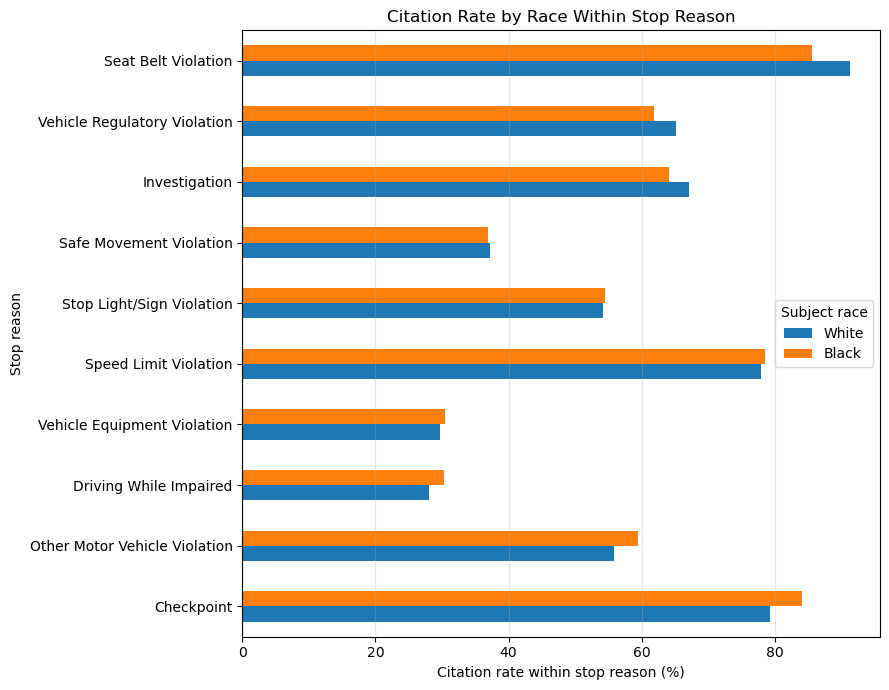

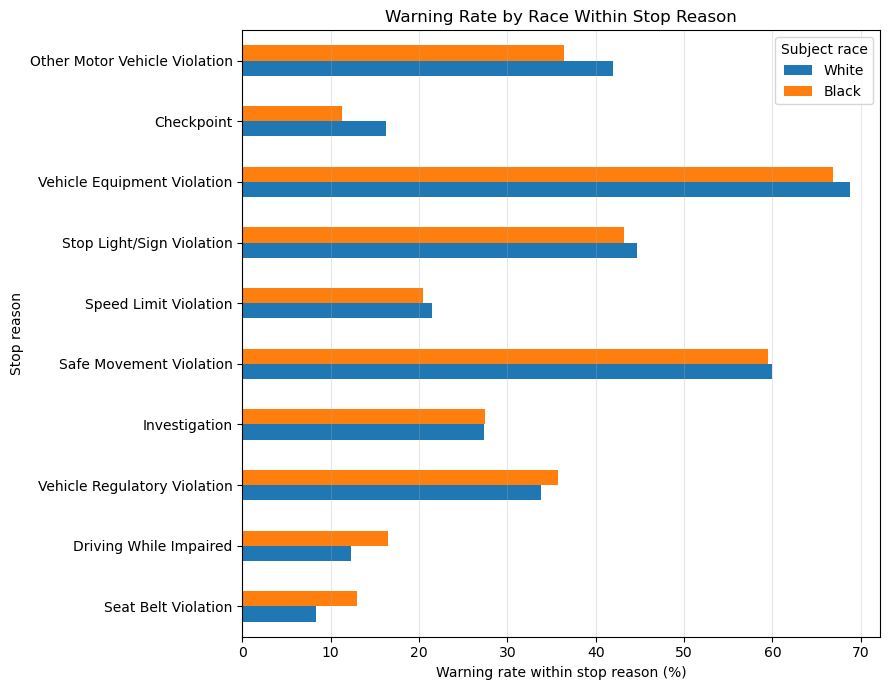

In [75]:
plot_data = (
    citation_by_reason_wide
    .loc[valid_reasons]
    .sort_values("black_minus_white", ascending=False)
    .head(15)
)

ax = plot_data[["white", "black"]].plot(
    kind="barh",
    figsize=(9, 7)
)

ax.set_title("Citation Rate by Race Within Stop Reason")
ax.set_xlabel("Citation rate within stop reason (%)")
ax.set_ylabel("Stop reason")

ax.legend(["White", "Black"], title="Subject race")
ax.grid(axis="x", alpha=0.3)

plt.tight_layout()
plt.show()

plot_data = (
    warning_by_reason_wide
    .loc[valid_reasons]
    .sort_values("black_minus_white", ascending=False)
    .head(15)
)

ax = plot_data[["white", "black"]].plot(
    kind="barh",
    figsize=(9, 7)
)

ax.set_title("Warning Rate by Race Within Stop Reason")
ax.set_xlabel("Warning rate within stop reason (%)")
ax.set_ylabel("Stop reason")

ax.legend(["White", "Black"], title="Subject race")
ax.grid(axis="x", alpha=0.3)

plt.tight_layout()
plt.show()

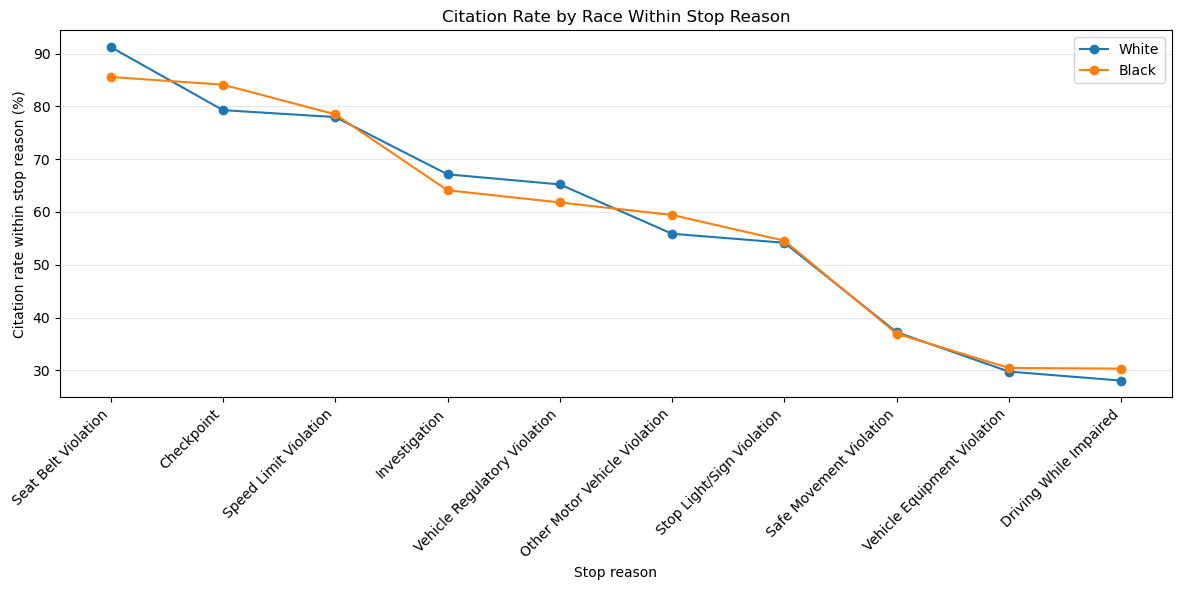

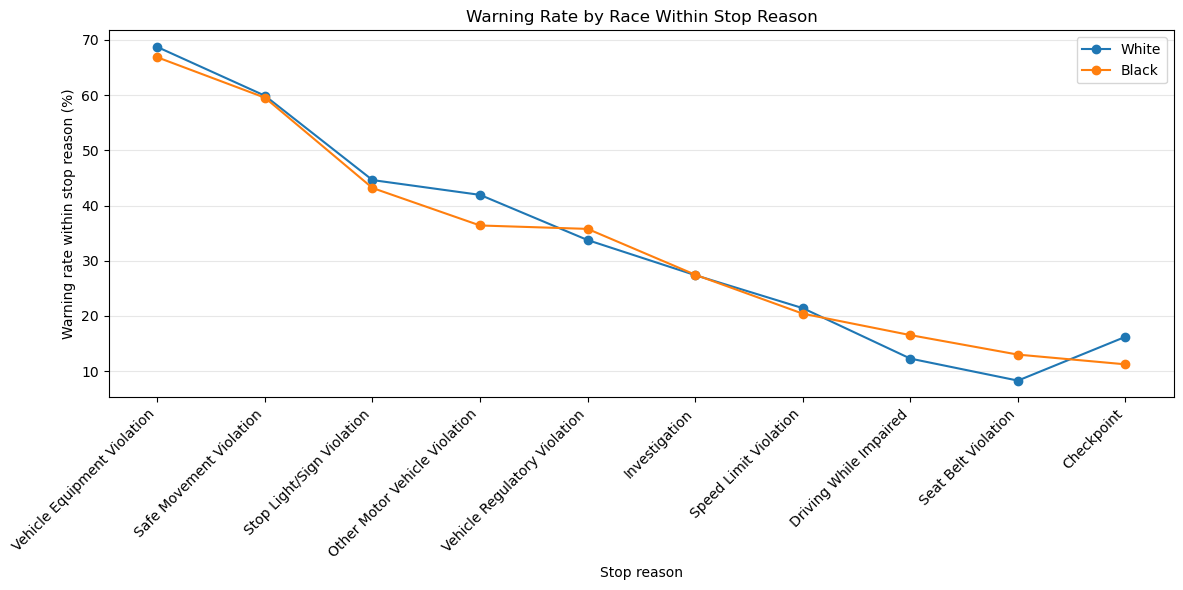

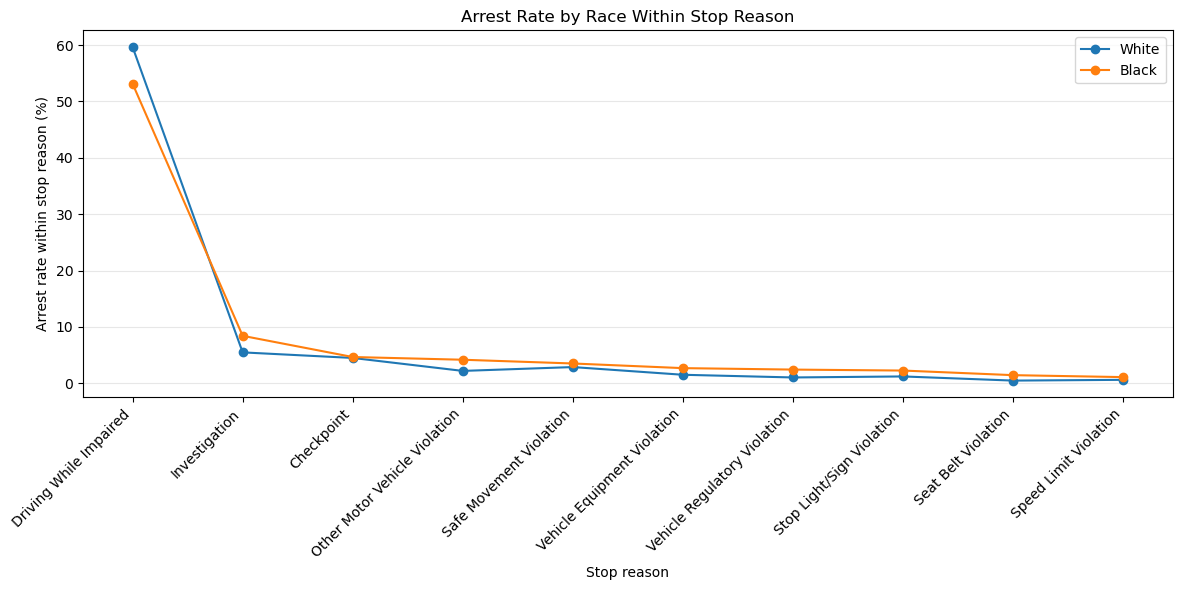

In [77]:
for chosen_outcome in ["citation", "warning", "arrest"]:

    outcome_by_reason = by_reason[
        by_reason["outcome"] == chosen_outcome
    ].copy()

    plot_data = outcome_by_reason.pivot(
        index="reason_for_stop",
        columns="subject_race",
        values="percent"
    ).fillna(0)

    plot_data = plot_data.loc[
        plot_data.index.intersection(valid_reasons)
    ]

    # Skip if that outcome does not exist in the data.
    if plot_data.empty:
        print(f"No data found for outcome: {chosen_outcome}")
        continue

    # Make sure both race columns exist.
    for race in ["white", "black"]:
        if race not in plot_data.columns:
            plot_data[race] = 0

    plot_data = plot_data.sort_values("black", ascending=False)

    plt.figure(figsize=(12, 6))

    plt.plot(
        plot_data.index,
        plot_data["white"],
        marker="o",
        label="White"
    )

    plt.plot(
        plot_data.index,
        plot_data["black"],
        marker="o",
        label="Black"
    )

    plt.title(f"{chosen_outcome.title()} Rate by Race Within Stop Reason")
    plt.xlabel("Stop reason")
    plt.ylabel(f"{chosen_outcome.title()} rate within stop reason (%)")

    plt.xticks(rotation=45, ha="right")
    plt.grid(axis="y", alpha=0.3)
    plt.legend()

    plt.tight_layout()
    plt.show()